# **Istanbul Rental Market & Walkability Analysis**
# Project P1: Problem & EDA

> **Project Link:** **[github.com/oykutugana/istanbul-rent-walkability-analysis](https://github.com/oykutugana/istanbul-rent-walkability-analysis)**

# 1. Problem Statement

**Real-World Problem**

Finding affordable and well-located housing in Istanbul has become a significant challenge due to high inflation and a complex rental market. For students and young professionals, the difficulty isn't just the price; it is finding a home that balances affordability with urban accessibility (walkability). Traditional real estate listings focus on size and age, but they often ignore the "hidden value" of being near transport hubs, universities, and social amenities.

---

**Why It Matters & Who Benefits**

This project matters because it transforms subjective "neighborhood feelings" into objective data.

* Students: Benefit by identifying "Sweet Spots"—districts that offer high accessibility at lower-than-average costs.

* Young Professionals: Benefit by understanding the "price premium" of walkability, helping them make informed financial decisions.

* Urban Analysts: Can use this model to see how infrastructure (like new metro lines) impacts local rental values.

---

**Prediction Target**
The primary variable this project aims to predict is price (The monthly rental fee of an apartment in Turkish Lira - TL).

---

**Task Type: Regression**

Because our target variable (price) is a continuous numerical value. We are not trying to put houses into categories (like "expensive" or "cheap"); we are trying to predict an exact monetary value based on features like area, room count, and our custom walkability score.

---

**Our Goal & Roadmap**

* Data Engineering: Transform raw, web-scraped real estate data into a structured, machine-learning-ready format.

* Feature Engineering: Develop a custom "Walkability Score" (integrating transport, university density, and social hubs) and a "Student Suitability Index."

* Correlation Analysis: Quantify the mathematical relationship between urban accessibility and rental pricing.

* Decision Support: Identify the most cost-effective districts optimized for student life in Istanbul.


# 2. Dataset Description

### **Feature Descriptions**

| Feature Name | Data Type | Description |
| :--- | :--- | :--- |
| **`price`** | Float | The cleaned monthly rent price in Turkish Lira (TL). |
| **`area_m2`** | Float | The gross internal area of the property in square meters ($m^2$). |
| **`room_count`** | Object | The raw room configuration string (e.g., "2+1", "1+0"). |
| **`district`** | Object | The standardized administrative district (İlçe) in Istanbul. |
| **`neighborhood`** | Object | The standardized neighborhood (Mahalle) of the property. |
| **`total_rooms`** | Float | **(Engineered)** The numerical sum of rooms and living areas derived from `room_count`. |
| **`walkability_score`** | Float | **(Engineered)** A normalized index (0-100) quantifying proximity to transport, universities, and social amenities. |
| **`student_score`** | Float | **(Engineered)** A weighted index (SSI) that balances the trade-off between accessibility and rental affordability. |

**Source & Data Acquisition**

The dataset used in this project consists of real estate listings for rental properties in Istanbul. The data was acquired via web-scraping from Sahibinden.com, Turkey's leading classifieds platform. This method was chosen to capture a "snapshot" of the current market dynamics and reflects real-world listing behaviors.

---

**Dataset Statistics**

* Number of Rows: 17,466 (Total raw entries)

* Number of Columns: 5 (Primary features before engineering)

---

**Known Limitations & Biases**

* Missing Values: The raw dataset contains significant gaps, especially in the neighborhood column (approx. 19% missing) and the price column (approx. 6% missing). These will require removal or imputation.

* Naming Inconsistencies: Some neighborhood names are incorrectly listed in the district column due to scraping artifacts, necessitating a "swapping" and standardization process.

* Geographic Bias: As the data is scraped from a single platform, it may favor districts with higher turnover or more digital-savvy real estate agents (e.g., Esenyurt and central districts might be over-represented).

* Temporal Snapshot: The data represents a specific point in time and does not account for seasonal fluctuations in the Istanbul rental market.

# 3. Data Loading & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import MinMaxScaler

# Gorsellestirmelerin notebook icinde gorunmesi icin
%matplotlib inline

# Veriyi yukle
df = pd.read_csv('../data/istanbul_emlak_data.csv')

# Ilk birkac satira goz atalim
df.head()

,price,area_m2,room_count,district,neighborhood
0,13.000 TL,85.0,2+1,Esenyurt,NaN
1,14.000 TL,95.0,2+1,Esenyurt,NaN
2,12.500 TL,130.0,3+1,Başakşehir,İkitelli
3,13.000 TL,90.0,2+1,Esenyurt,NaN
4,14.000 TL,150.0,3+1,Esenyurt,NaN


In [2]:
# ════════════════════════════════════════════════════════════════
#  GLOBAL VISUAL THEME — Istanbul Rental Market Analysis
#  Bu hucre tum notebook boyunca gecerli olacak renk/stil tanimlar
# ════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# ── Renk paleti ──────────────────────────────────────────────────
C_PRIMARY    = '#2E86AB'   # Koyu mavi  — ana bar/histogram rengi
C_SECONDARY  = '#E84855'   # Kırmızı    — mean çizgisi / vurgu
C_ACCENT     = '#F9A03F'   # Turuncu    — median çizgisi / ikincil vurgu
C_GREEN      = '#3BB273'   # Yeşil      — pozitif/iyi metrik
C_DARK       = '#1B1F3B'   # Lacivert   — başlık / koyu metin
C_LIGHT      = '#F7F9FC'   # Açık gri   — arka plan / bbox

# Kategorik sıralı palet (bar chart, scatter kategoriler vb.)
CAT_PALETTE  = ['#2E86AB', '#E84855', '#F9A03F', '#3BB273',
                '#9B5DE5', '#F15BB5', '#00BBF9', '#00F5D4',
                '#FEE440', '#FB5607']

# Isı haritaları için
CMAP_DIV     = 'RdYlBu_r'   # Korelasyon heatmap
CMAP_SEQ     = 'Blues'       # Sıralı tek renkli
CMAP_MISSING = 'magma'       # Eksik veri heatmap

# ── Matplotlib rcParams ──────────────────────────────────────────
mpl.rcParams.update({
    # Font
    'font.family'        : 'DejaVu Sans',
    'font.size'          : 11,
    'axes.titlesize'     : 14,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 12,
    'xtick.labelsize'    : 10,
    'ytick.labelsize'    : 10,
    'legend.fontsize'    : 10,
    'figure.titlesize'   : 16,
    'figure.titleweight' : 'bold',

    # Figür
    'figure.figsize'     : (12, 5),
    'figure.dpi'         : 110,
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : '#F7F9FC',
    'axes.edgecolor'     : '#CCCCCC',
    'axes.grid'          : True,
    'grid.color'         : '#DDDDDD',
    'grid.linestyle'     : '--',
    'grid.alpha'         : 0.6,

    # Çizgiler & işaretçiler
    'lines.linewidth'    : 2.0,
    'patch.edgecolor'    : 'white',

    # Kaydetme
    'savefig.dpi'        : 150,
    'savefig.bbox'       : 'tight',
    'savefig.facecolor'  : 'white',
})

# ── Seaborn tema ─────────────────────────────────────────────────
sns.set_theme(
    style   = 'whitegrid',
    palette = CAT_PALETTE,
    rc      = {
        'axes.facecolor'  : '#F7F9FC',
        'figure.facecolor': 'white',
    }
)

In [3]:
# Display technical summary of the dataframe
print("\n--- Dataframe Information (.info()) ---")
df.info()

# Display statistical summary for numerical features
print("\n--- Statistical Summary (.describe()) ---")
display(df.describe())

,area_m2
count,16403.000000
mean,103.235497
std,33.973672
min,1.201000
25%,80.000000
50%,95.000000
75%,125.000000
max,500.000000


In [4]:
# Reporting the structure
print(f"Dataset Shape: {df.shape}")
print("\nData Types of Each Column:")
print(df.dtypes)

Dataset Shape: (17466, 5)

Data Types of Each Column:
price            object
area_m2         float64
room_count       object
district         object
neighborhood     object
dtype: object


### _Stage1: Initial Data Inspection(Missing Values)_
First, we look at the raw data. The yellow lines in the Heatmap show where information is missing. We need to see how "dirty" our data is before cleaning.

This heatmap serves as the initial "Data Quality Audit." It visualizes the gaps in our raw dataset where information was not provided during the scraping process.

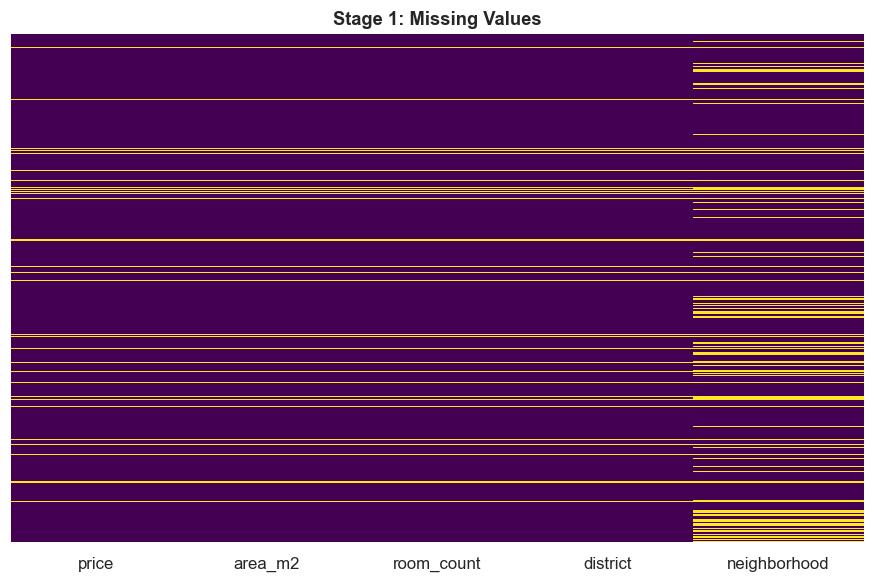

In [5]:
# Temizlik oncesi heat map
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Stage 1: Missing Values")

# Kiyaslama icin png kaydet.
plt.savefig('p1_plots/stage1_missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

_The prominent yellow streaks in the neighborhood and price columns indicate significant data loss, highlighting the immediate need for a robust cleaning pipeline to prevent model bias._

In [6]:
print("Eksik veri sayisi (Raw Data):")
print(df.isnull().sum())

Eksik veri sayisi (Raw Data):
price           1063
area_m2         1063
room_count      1063
district        1063
neighborhood    3326
dtype: int64


_We identified missing values using .isnull().sum(). Listings missing critical features such as price, area_m2, or district were dropped. Justification: Since these are our primary predictors and target variable, imputing them would introduce significant noise and bias into the regression model._

**Summary for Section 3**

* Dataset Shape: The raw dataset contains 17,466 rows and 5 columns.

* Column Types: * price, room_count, district, and neighborhood are currently Object (String) types.

* area_m2 is the only column recognized as Float64.

---

**Critical Issues Identified:**

* The price column needs to be converted from string (e.g., "15.000 TL") to numerical for analysis.

* There are significant missing values in neighborhood and price columns that must be addressed in the cleaning stage.

* The statistical summary (describe()) currently only shows area_m2 because it is the only numerical column in the raw state.

# 4. Data Cleaning
Step 4.1: Fixing Incorrect Data Types & Category Standardization

Step 4.2: Feature Engineering (Walkability & Student Scores)

Step 4.3: Outlier Analysis & Domain-Based Removal

### 4.1 Fixing Incorrect Data Types & Category Standardization 

Raw data contained strings like 'TL' and 'm2'. We cast these to floats.
Justification: Machine learning algorithms require numerical input for mathematical operations and distance calculations.We change strings to floats.

**What we do here:**
* Remove "TL" and dots from Price.
* Remove "m2" from Area.
* Change "2+1" room count to total number (3.0).
* Fix District & Neighborhood:Some neighborhoods (like Taksim) were in the District column. We moved them to the correct place.

_We checked for duplicate rows using .duplicated() and removed them. Justification: Real estate platforms often have duplicate listings for the same property. Removing them ensures our model doesn't 'overlearn' from the same data point, preventing over-fitting._

In [7]:
# Duplicates
print(f"Duplicates found: {df.duplicated().sum()}")
df = df.drop_duplicates()

# Fiyati temizle ("25.000 TL" -> 25000)
def clean_price(price_str):
    if pd.isna(price_str): return np.nan
    # Rakam disindaki her seyi (TL, nokta vb.) temizle
    price = re.sub(r'[^\d]', '', str(price_str))
    return float(price) if price else np.nan

# Metrekareyi temizle ("120 m2" -> 120)
def clean_m2(m2_str):
    if pd.isna(m2_str): return np.nan
    # Sadece 'm2' yazisini ve bosluklari temizle, noktaya dokunma
    m2 = str(m2_str).replace('m2', '').replace(' ', '').strip()
    return float(m2) if m2 else np.nan

# Oda sayisini sayisal toplama cevir.
def simple_room_count(room_str):
    # Bos veri veya 'stüdyo' kontrolu
    if pd.isna(room_str) or 'stüdyo' in str(room_str).lower():
        return 1.0

    try:
        # "+" isaretinden bol ve her parcayi float yapip topla.
        return sum(float(part) for part in str(room_str).split('+'))
    except:
        # Eger garip bir format gelirse (bosluk vs) 0 don.
        return 0.0

Duplicates found: 4004


In [8]:
# Uygula.
df['price'] = df['price'].apply(clean_price)
df['area_m2'] = df['area_m2'].apply(clean_m2)
df['total_rooms'] = df['room_count'].apply(simple_room_count)

# Sutunlari temizle.
df['room_count'] = df['room_count'].str.strip()

print("Temizleme sonrası veri tipleri:\n", df.dtypes)
df.head()

,price,area_m2,room_count,district,neighborhood,total_rooms
0,13000.0,85.0,2+1,Esenyurt,NaN,3.0
1,14000.0,95.0,2+1,Esenyurt,NaN,3.0
2,12500.0,130.0,3+1,Başakşehir,İkitelli,4.0
3,13000.0,90.0,2+1,Esenyurt,NaN,3.0
4,14000.0,150.0,3+1,Esenyurt,NaN,4.0


In [9]:
# Yazim hatalarini ve karakterleri standartlastir.
# Analizlerin ve Walkability Score'un dogru calismasi icin isimlerin birebir uymasi gerekir.
df['district'] = df['district'].replace({
    'Besiktas': 'Beşiktaş', 'Kadikoy': 'Kadıköy', 'Sisli': 'Şişli',
    'Uskudar': 'Üsküdar', 'Beyoglu': 'Beyoğlu', 'Basaksehir': 'Başakşehir',
    'Arnavutkoy': 'Arnavutköy', 'Bagcilar': 'Bağcılar', 'Bahcelievler': 'Bahçelievler',
    'Bakirkoy': 'Bakırköy', 'Bayrampasa': 'Bayrampaşa', 'Beylikduzu': 'Beylikdüzü',
    'Buyukcekmece': 'Büyükçekmece', 'Catalca': 'Çatalca', 'Cekmekoy': 'Çekmeköy',
    'Eyupsultan': 'Eyüpsultan', 'Gaziosmanpasa': 'Gaziosmanpaşa', 'Gungoren': 'Güngören',
    'Kagithane': 'Kağıthane', 'Kucukcekmece': 'Küçükçekmece', 'Sariyer': 'Sarıyer',
    'Sile': 'Şile', 'Umraniye': 'Ümraniye', 'Zeytinburnu': 'Zeytinburnu'
})

In [10]:
# Mahalle-Ilce Eslestirme
# Ilce sutununa kacmis olan mahalleleri ve bagli olduklari asil ilceleri tanimla.
location_fix = {
    # Beyoglu Mahalleleri
    'Taksim': 'Beyoğlu', 'Cihangir': 'Beyoğlu', 'Tarlabaşı': 'Beyoğlu', 'Kasımpaşa': 'Beyoğlu',
    'Halıcıoğlu': 'Beyoğlu', 'Yenişehir': 'Beyoğlu', 'Pürtelaş': 'Beyoğlu', 'İstiklal': 'Beyoğlu',
    'Kemankeş': 'Beyoğlu', 'Arapcami': 'Beyoğlu', 'Gümüşsuyu': 'Beyoğlu', 'Sütlüce': 'Beyoğlu',
    # Şişli Mahalleleri
    'Nişantaşı': 'Şişli', 'Mecidiyeköy': 'Şişli', 'Feriköy': 'Şişli', 'Fulya': 'Şişli',
    'Gayrettepe': 'Şişli', 'Harbiye': 'Şişli', 'Teşvikiye': 'Şişli', 'Okmeydanı': 'Şişli',
    'Gülbahar': 'Şişli', 'Halide Edip': 'Şişli', 'Duatepe': 'Şişli', 'Bozkurt': 'Şişli',
    'Meşrutiyet': 'Şişli', 'Esentepe': 'Şişli', 'Kuştepe': 'Şişli', 'Bomonti': 'Şişli',
    # Kadikoy Mahalleleri
    'Acıbadem': 'Kadıköy', 'Moda': 'Kadıköy', 'Fenerbahçe': 'Kadıköy', 'Caddebostan': 'Kadıköy',
    'Göztepe': 'Kadıköy', 'Bostancı': 'Kadıköy', 'Erenköy': 'Kadıköy', 'Suadiye': 'Kadıköy',
    'Sahrayıcedit': 'Kadıköy', 'Hasanpaşa': 'Kadıköy', 'Rasimpaşa': 'Kadıköy', 'Zühtüpaşa': 'Kadıköy',
    'Fikirtepe': 'Kadıköy', 'Merdivenköy': 'Kadıköy', 'Kozyatağı': 'Kadıköy', '19 Mayıs': 'Kadıköy',
    'Caferağa': 'Kadıköy', 'Kalamış': 'Kadıköy',
    # Besiktas Mahalleleri
    'Ortaköy': 'Beşiktaş', 'Bebek': 'Beşiktaş', 'Etiler': 'Beşiktaş', 'Levent': 'Beşiktaş',
    'Ulus': 'Beşiktaş', 'Gayrettepe': 'Beşiktaş', 'Levazım': 'Beşiktaş', 'Kuruçeşme': 'Beşiktaş',
    'Balmumcu': 'Beşiktaş', 'Akat': 'Beşiktaş', 'Dikilitaş': 'Beşiktaş', 'Yıldız': 'Beşiktaş',
    # Uskudar Mahalleleri
    'Kuzguncuk': 'Üsküdar', 'Beylerbeyi': 'Üsküdar', 'Çengelköy': 'Üsküdar', 'Kandilli': 'Üsküdar',
    'Altunizade': 'Üsküdar', 'Burhaniye': 'Üsküdar', 'Selimiye': 'Üsküdar', 'Zeynep Kamil': 'Üsküdar',
    'Bağlarbaşı': 'Üsküdar', 'Doğancılar': 'Üsküdar', 'Küçüksu': 'Üsküdar', 'Kuleli': 'Üsküdar',
    # Maltepe Mahalleleri
    'Küçükyalı': 'Maltepe', 'İdealtepe': 'Maltepe', 'Zümrütevler': 'Maltepe', 'Feyzullah': 'Maltepe',
    'Cevizli': 'Maltepe', 'Başıbüyük': 'Maltepe', 'Aydınevler': 'Maltepe', 'Yalı': 'Maltepe',
    # Sariyer Mahalleleri
    'Büyükdere': 'Sarıyer', 'İstinye': 'Sarıyer', 'Rumelihisarı': 'Sarıyer', 'Tarabya': 'Sarıyer',
    'Emirgan': 'Sarıyer', 'Bahçeköy': 'Sarıyer', 'Zekeriyaköy': 'Sarıyer', 'Yeniköy': 'Sarıyer',
    # Zeytinburnu Mahalleleri
    'Merkezefendi': 'Zeytinburnu', 'Beştelsiz': 'Zeytinburnu', 'Çırpıcı': 'Zeytinburnu', 'Seyitnizam': 'Zeytinburnu',
    # Atasehir Mahalleleri
    'İçerenköy': 'Ataşehir', 'Küçükbakkalköy': 'Ataşehir', 'Barbaros': 'Ataşehir', 'Kayışdağı': 'Ataşehir',
    # Umraniye Mahalleleri
    'Çakmak': 'Ümraniye', 'Ihlamurkuyu': 'Ümraniye', 'Dudullu': 'Ümraniye', 'Atakent': 'Ümraniye', 'Esenevler': 'Ümraniye',
    # Bagcilar Mahalleleri
    'Güneşli': 'Bağcılar', 'Mahmutbey': 'Bağcılar', 'Kirazlı': 'Bağcılar', 'Hürriyet': 'Bağcılar',
    # Eyupsultan Mahalleleri
    'Alibeyköy': 'Eyüpsultan', 'Göktürk': 'Eyüpsultan', 'Kemerburgaz': 'Eyüpsultan', 'Yeşilpınar': 'Eyüpsultan',
    # Diger
    'Kumburgaz': 'Büyükçekmece', 'Mimarsinan': 'Büyükçekmece', 'Tepecik': 'Büyükçekmece',
    'Celaliye(Kamiloba)': 'Büyükçekmece', 'Kamiloba': 'Büyükçekmece',
    'İkitelli': 'Başakşehir', 'Sultançiftliği': 'Sultangazi', 'Anadoluhisarı': 'Beykoz'
}

# Mahalle eklerini ve bosluklari temizle ("Taksim Mh." -> "Taksim")
df['district'] = df['district'].str.replace(r'\s+(Mh\.?|Mah\.?|Mahallesi)$', '', regex=True).str.strip()
df['neighborhood'] = df['neighborhood'].str.replace(r'\s+(Mh\.?|Mah\.?|Mahallesi)$', '', regex=True).str.strip()

# Swapping: Eger ilce sutununda bir mahalle adi varsa onu once 'neighborhood' sutununa tasi,
# sonra 'district' sutununu gercek ilcesiyle guncelle.
for wrong_name, correct_district in location_fix.items():
    # Eger mahalle bilgisi bossa, ilce sutunundaki mahalle adini oraya kopyala.
    df.loc[(df['district'] == wrong_name) & (df['neighborhood'].isna()), 'neighborhood'] = wrong_name
    # Sonra ilce adini duzelt.
    df.loc[df['district'] == wrong_name, 'district'] = correct_district

# Bos mahalleleri "Merkez" olarak isaretle.(Swapping sonrası hala verisi olmayan yerler artik resmen o ilcenin 'Merkez'idir.)
df['neighborhood'] = df['neighborhood'].fillna('Merkez')

print("Konum duzeltme ve veri kaydirma tamamlandi.")
print(f"Guncel Benzersiz Ilce Sayisi: {df['district'].nunique()}")

Konum duzeltme ve veri kaydirma tamamlandi.
Guncel Benzersiz Ilce Sayisi: 80


_We standardized district names and moved neighborhood names accidentally placed in the 'District' column back to their correct place._

_Justification: Categorical consistency is vital for our Walkability Score calculation, as it relies on exact district-level matches from external data sources._

### 4.2 Feature Engineering

### Walkability Score (Urban Accessibility)

Students need to walk to university or transport.The walkability score is a custom feature designed to quantify how accessible a property is to essential urban amenities.

The score is computed based on the presence of nearby facilities such as:
* Public transportation
* Markets and grocery stores
* Universities
* Social areas

Each component contributes to the total score with predefined weights:
* Transportation (0.5): Proximity to Metro, Metrobus, and Ferry lines.
* Universities (0.3): Concentration of campus locations and faculties.
* Social & Markets (0.2): Availability of cafes, libraries, and grocery stores.

The final score is normalized to a scale between 0 and 100.

$$Score = (Transport \times 0.5) + (University \times 0.3) + (Social \times 0.2)$$

In [11]:
# Ham Istatistikler (IBB, YÖK ve Sosyal Endeks yaklaşık verileri)
# 1. stations: Metro, Metrobus, Marmaray, Vapur durak sayisi
# 2. univ_campuses: Ilce sinirlarindaki aktif yerleske/fakulte sayisi
# 3. social_points: Sosyal imkanlar (kafe, kutuphane, yesil alan) yogunluk puani (0-100)
raw_stats = {
    'Beşiktaş':    {'stations': 12, 'univ_campuses': 10, 'social_points': 95},
    'Kadıköy':     {'stations': 15, 'univ_campuses': 6,  'social_points': 98},
    'Beyoğlu':     {'stations': 14, 'univ_campuses': 5,  'social_points': 100},
    'Şişli':       {'stations': 14, 'univ_campuses': 8,  'social_points': 90},
    'Fatih':       {'stations': 18, 'univ_campuses': 12, 'social_points': 75},
    'Üsküdar':     {'stations': 10, 'univ_campuses': 5,  'social_points': 80},
    'Sarıyer':     {'stations': 8,  'univ_campuses': 9,  'social_points': 80},
    'Ataşehir':    {'stations': 8,  'univ_campuses': 4,  'social_points': 80},
    'Bakırköy':    {'stations': 9,  'univ_campuses': 4,  'social_points': 85},
    'Zeytinburnu': {'stations': 12, 'univ_campuses': 4,  'social_points': 65},
    'Ümraniye':    {'stations': 10, 'univ_campuses': 2,  'social_points': 65},
    'Eyüpsultan':  {'stations': 9,  'univ_campuses': 3,  'social_points': 60},
    'Kağıthane':   {'stations': 7,  'univ_campuses': 3,  'social_points': 55},
    'Kartal':      {'stations': 8,  'univ_campuses': 2,  'social_points': 60},
    'Avcılar':     {'stations': 6,  'univ_campuses': 7,  'social_points': 50},
    'Maltepe':     {'stations': 7,  'univ_campuses': 4,  'social_points': 65},
    'Bağcılar':    {'stations': 12, 'univ_campuses': 3,  'social_points': 45},
    'Esenyurt':    {'stations': 3,  'univ_campuses': 2,  'social_points': 35},
    'Beylikdüzü':  {'stations': 4,  'univ_campuses': 2,  'social_points': 45},
    'Silivri':     {'stations': 1,  'univ_campuses': 1,  'social_points': 20}
}

# Ham veriyi DataFrame'e cevir.
stats_df = pd.DataFrame.from_dict(raw_stats, orient='index')

# Normalizasyon (0-100): En yuksek sayiya sahip olan ilce 100 puan alacak sekilde
def normalize(column):
    return (column - column.min()) / (column.max() - column.min()) * 100

stats_df['transport_score'] = normalize(stats_df['stations'])
stats_df['univ_score'] = normalize(stats_df['univ_campuses'])
stats_df['social_score'] = normalize(stats_df['social_points'])

# Formülü Uygula: Transport (%50), University (%30), Social (%20)
stats_df['final_walkability_score'] = (
    (stats_df['transport_score'] * 0.5) +
    (stats_df['univ_score'] * 0.3) +
    (stats_df['social_score'] * 0.2)
).round(2)

# Veriye uygula.
# Onemli: Gizli bosluklari temizleyerek eslesmeyi garanti altina aliyoruz.
df['district'] = df['district'].str.strip()
final_metrics_map = stats_df['final_walkability_score'].to_dict()
df['walkability_score'] = df['district'].map(final_metrics_map).fillna(10.0)

# Kontrol et.
print("Veriden Türetilmiş Skorlar (Normalizasyon Sonrası):")
print(stats_df[['transport_score', 'univ_score', 'social_score', 'final_walkability_score']].sort_values(by='final_walkability_score', ascending=False))

Veriden Türetilmiş Skorlar (Normalizasyon Sonrası):
             transport_score  univ_score  social_score  \
Fatih             100.000000  100.000000         68.75   
Beşiktaş           64.705882   81.818182         93.75   
Şişli              76.470588   63.636364         87.50   
Kadıköy            82.352941   45.454545         97.50   
Beyoğlu            76.470588   36.363636        100.00   
Sarıyer            41.176471   72.727273         75.00   
Üsküdar            52.941176   36.363636         75.00   
Zeytinburnu        64.705882   27.272727         56.25   
Bakırköy           47.058824   27.272727         81.25   
Bağcılar           64.705882   18.181818         31.25   
Ataşehir           41.176471   27.272727         75.00   
Ümraniye           52.941176    9.090909         56.25   
Eyüpsultan         47.058824   18.181818         50.00   
Avcılar            29.411765   54.545455         37.50   
Maltepe            35.294118   27.272727         56.25   
Kartal             4

### Saving the Scored Dataset
Now our data has a "Walkability Score." We save it as a new CSV file.

In [12]:
# index=False (basa gereksiz 0,1,2... sutunu eklemesin)
df.to_csv('../data/istanbul_emlak_walkability.csv', index=False)

print("Veri 'istanbul_emlak_walkability.csv' adıyla kaydedildi.")

Veri 'istanbul_emlak_walkability.csv' adıyla kaydedildi.


### Student-Friendly Score

A prime location is not necessarily "ideal" for a student if the rent is prohibitive. This index identifies "Sweet Spots" by balancing Accessibility with Affordability.

**Logic:**

* Inverted Price Score: Since lower rent is better for students, we normalize the price and subtract it from 1 (1−Price
norm
​
 ), ensuring that cheaper listings receive a higher score.

* Optimization: It filters out ultra-luxury areas and highlights neighborhoods where high walkability meets reasonable costs.

**Formula:**

Score
Student
​
 =(Score
Walkability
​
 ×0.5)+(Inverted_Price_Score×0.5)
Weighting: By assigning 50% to Walkability and 50% to Affordability, this metric pinpoints the most optimized residential zones for the student demographic in Istanbul.

In [13]:
# Scaler olustur.
scaler = MinMaxScaler()

# 2. Fiyati normalize et (0-1 arası) ve tersine cevir.
# (Yuksek fiyat = Dusuk puan olmasi icin 1'den cikar.)
df['price_normalized'] = scaler.fit_transform(df[['price']])
df['price_score'] = (1 - df['price_normalized']) * 100

# Ogrenci Uygunluk Skorunu Hesapla (%50 Yurunebilirlik, %50 Ucuzluk)
df['student_score'] = (df['walkability_score'] * 0.5) + (df['price_score'] * 0.5)

# 2 basamaga yuvarla
df['student_score'] = df['student_score'].round(2)

# Ara islemleri temizleyip sadece final skorunu tut.
df.drop(['price_normalized', 'price_score'], axis=1, inplace=True)

# Kontrol: En yuksek skorlu 5 ilce/mahalle
print(df[['district', 'neighborhood', 'price', 'walkability_score', 'student_score']].sort_values(by='student_score', ascending=False).head())

     district neighborhood    price  walkability_score  student_score
9459    Fatih       Merkez  10000.0              93.75          96.88
21      Fatih      Akdeniz  10000.0              93.75          96.88
1015    Fatih       Haseki  10000.0              93.75          96.88
970     Fatih    Fevzipaşa  10000.0              93.75          96.88
35      Fatih        Fener  12000.0              93.75          96.16


### Saving the Scored Dataset
Now our data has a "Student Score." We save it as a new CSV file.

In [14]:
df.to_csv('../data/istanbul_emlak_student.csv', index=False)

print("Veri 'istanbul_emlak_student.csv' adıyla kaydedildi.")

Veri 'istanbul_emlak_student.csv' adıyla kaydedildi.


### _Stage 2: Outlier Analysis (Visual Identification)_
We check the data before removing outliers.
Some data is not realistic. For example, houses with 1500 $m^2$ area.
These "Outliers" break our graphs and models.
We see these spikes in the red histograms below.
This "noise" makes our graphs look bad.

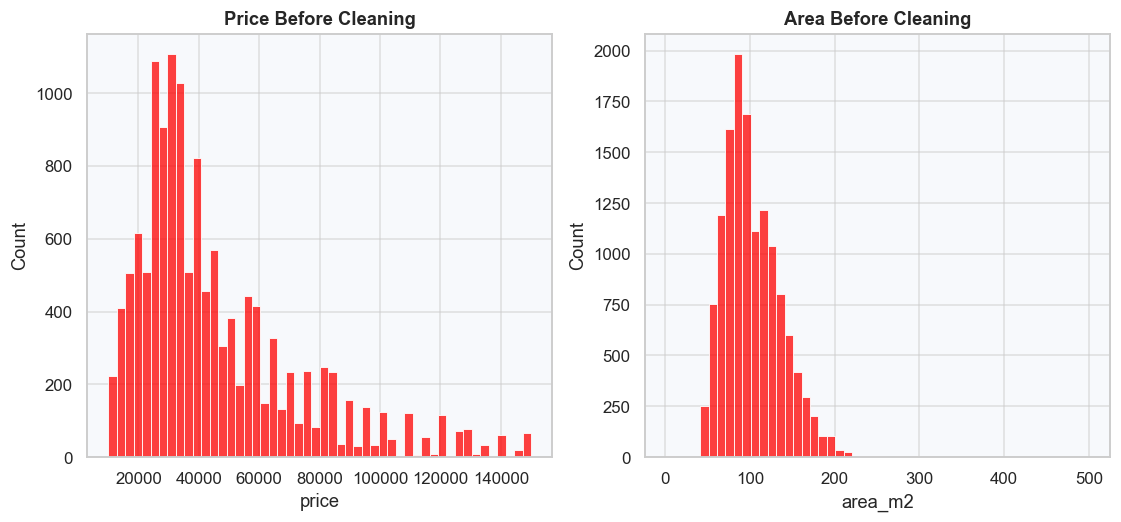

In [15]:
df = pd.read_csv('../data/istanbul_emlak_walkability.csv')

# Fiyat dagilimi (Kirmizi)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=50, color='red')
plt.title('Price Before Cleaning')

# Metrekare dagilimi (Kirmizi)
plt.subplot(1, 2, 2)
sns.histplot(df['area_m2'], bins=50, color='red')
plt.title('Area Before Cleaning')

# Kiyaslama icin png kaydet.
plt.savefig('p1_plots/stage2_dirty_distribution.png', dpi=300)
plt.show()

_The extreme right-skewness and 'spikes' at near-zero or million-plus values represent unrealistic outliers (e.g., 1 TL rents or massive land plots) that would degrade the performance of any regression model._

### 4.3 Outlier Analysis & Domain-Based Removal

### Handling Missing Values and Outliers

Method: Domain-Based Threshold Filtering

To ensure data quality and reliability, both missing values and unrealistic observations were addressed.

First, rows with missing critical values were removed. Listings without essential attributes such as price, area (m²), or district were excluded, as they cannot contribute to meaningful analysis or modeling.

Outliers were handled using domain-based threshold filtering, where limits were defined based on knowledge of the Istanbul real estate market rather than purely statistical methods.

What we do:
* Missing Value Removal: We eliminated incomplete records using dropna. Listings missing critical features like price, area, or district cannot be used for accurate machine learning predictions.
* Price Filtering: We kept listings between 5,000 TL and 200,000 TL. This removes "noise" like fake daily rentals (very low) or luxury mansions/errors (extreme high) that would skew the model's average.
* Area Filtering: We set a logical limit between 30 m2 and 500 m2.This ensures the model focuses on standard residential apartments, removing tiny storage units or massive industrial plots.

Result: This filtering process reduces noise and improves the representativeness of the dataset, allowing for more reliable exploratory analysis and better generalization in subsequent regression models.

In [16]:
df = pd.read_csv('../data/istanbul_emlak_student.csv')

# Null veya kritik verisi eksik olan satirlari sil. (Fiyat ve metrekare olmayan satirlar isimize yaramaz)
df = df.dropna(subset=['price', 'area_m2', 'district'])

# Outliers: Istanbul icin gercekci olmayan kira ve metrekare
df = df[(df['price'] > 5000) & (df['price'] < 200000)] # 5k altı ve 200k ustu gitsin
df = df[(df['area_m2'] > 30) & (df['area_m2'] < 500)] # 30m2 alti ve 500m2 ustu gitsin

# Sonuclari kontrol et
print(f"Temizlik sonrası kalan ilan sayısı: {len(df)}")
df.head()

,price,area_m2,room_count,district,neighborhood,total_rooms,walkability_score,student_score
0,13000.0,85.0,2+1,Esenyurt,Merkez,3.0,12.36,55.11
1,14000.0,95.0,2+1,Esenyurt,Merkez,3.0,12.36,54.75
2,12500.0,130.0,3+1,Başakşehir,İkitelli,4.0,10.00,54.11
3,13000.0,90.0,2+1,Esenyurt,Merkez,3.0,12.36,55.11
4,14000.0,150.0,3+1,Esenyurt,Merkez,4.0,12.36,54.75


_While IQR is a standard statistical method, we opted for Domain-Based Filtering because Istanbul's rental market has a very high variance. Using IQR might accidentally remove valid luxury listings or keep 'fake' low-priced listings. Setting manual thresholds (5k-200k TL) ensures we keep realistic residential data_

### Saving the Final Dataset
Now our data is clean and has a "Walkability Score."
We save it as a new CSV file.

In [17]:
# index=False (basa gereksiz 0,1,2... sutunu eklemesin)
df.to_csv('../data/istanbul_emlak_final.csv', index=False)

print("Temizlenmiş veri 'istanbul_emlak_final.csv' adıyla kaydedildi.")

Temizlenmiş veri 'istanbul_emlak_final.csv' adıyla kaydedildi.


### _Stage 3: Final Data Quality Check & Comparison_
Now we check the data again.
The Heatmap should be solid (no yellow lines).
The Green histograms show that our data is now realistic and "Clean."

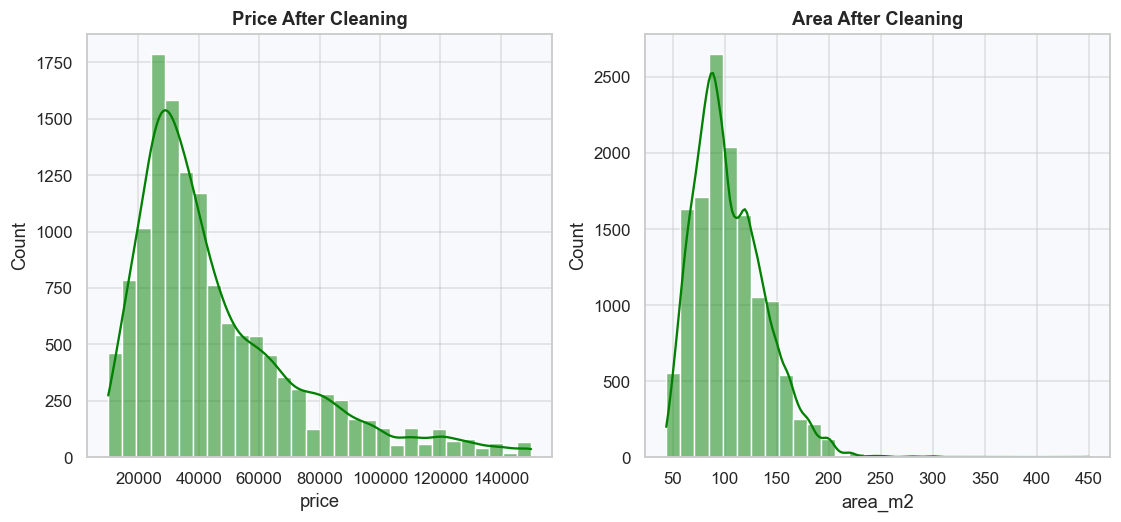

In [18]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')
# Heat Map: Temizlik ve Outlier isleminden sonraki eksik veri görsellestirmesi
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Eksik Veri Matrisi (AFTER CLEANING)")
plt.show()

# Sutun bazinda eksik veri sayilarini tekrar kontrol et. (hepsi 0 olmali)
print("Eksik değer sayısı (Missing values count):\n")
print(df.isnull().sum())

# Temizlik sonrasi dagilim (Yesil = daha duzenli)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=30, kde=True, color='green')
plt.title('Price After Cleaning')

plt.subplot(1, 2, 2)
sns.histplot(df['area_m2'], bins=30, kde=True, color='green')
plt.title('Area After Cleaning')

# Kiyaslama icin png kaydet.
plt.savefig('p1_plots/stage3_final_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

_The solid, uniform color profile confirms a 100% complete dataset; our 'Standardization Gatekeeper' has ensured the data is now structurally sound and ML-Ready._

### Data Processing

We successfully transformed raw real estate data into a structured, student-friendly dataset.
Below is the step-by-step visualization of our cleaning process:

---

#### **Stage 1: The Starting Point (Raw Data)**
We started with "dirty" data. The yellow lines in the heatmap represent missing information that could mislead our model.
<img src="p1_plots/stage1_missing_values.png" width="100%">

---

#### **Stage 2: Feature Engineering (Walkability Score Integration)**
In this stage, we standardized district names and calculated our custom Walkability Index for every listing.
<img src="p1_plots/stage2_dirty_distribution.png" width="100%">

---

#### **Stage 3: Final Cleaning & Outlier Removal (ML-Ready)**
Our final dataset has **zero missing values** (solid purple) and includes our custom **Walkability Score**. We are now ready for the Regression phase.
<img src="p1_plots/stage3_final_heatmap.png" width="100%">

---

# 5. Univariate Analysis

In this section, we analyze the distribution and statistical properties of each feature individually.

### **5.1. Numerical Features Analysis: Distribution & Skewness**

To understand the distribution of our numerical features and identify potential biases or the need for transformations, we visualize each variable using histograms with Kernel Density Estimation (KDE).

**Key Metrics Reported:**
* **Mean & Median:** To identify the central tendency.
* **Standard Deviation:** To measure the spread of data.
* **Skewness:** To quantify the asymmetry of the distribution (Critical for Phase 2 Regression strategy).


| Feature | Mean | Median | Std Dev | Skewness | Interpretation |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Price (Target)** | ~44,355 | 35,000 | ~28,830 | 1.36 | **Highly Right-Skewed.** Majority of listings are in the lower price range. |
| **Area ($m^2$)** | 103.2 | 95.0 | 33.9 | 0.99 | **Moderately Right-Skewed.** Typical apartments are around 90-100 $m^2$. |
| **Total Rooms** | 3.10 | 3.0 | 0.85 | 0.19 | **Nearly Symmetric.** Most listings are standard 2+1 (3 total rooms) units. |
| **Walkability** | 14.49 | 10.0 | 15.6 | 3.42 | **Highly Skewed.** High scores are concentrated in specific central districts. |
| **Student Score** | 44.97 | 46.7 | 11.2 | -0.22 | **Symmetric.** Balanced distribution across the suitability index. |

#### Numerical Features Histogram

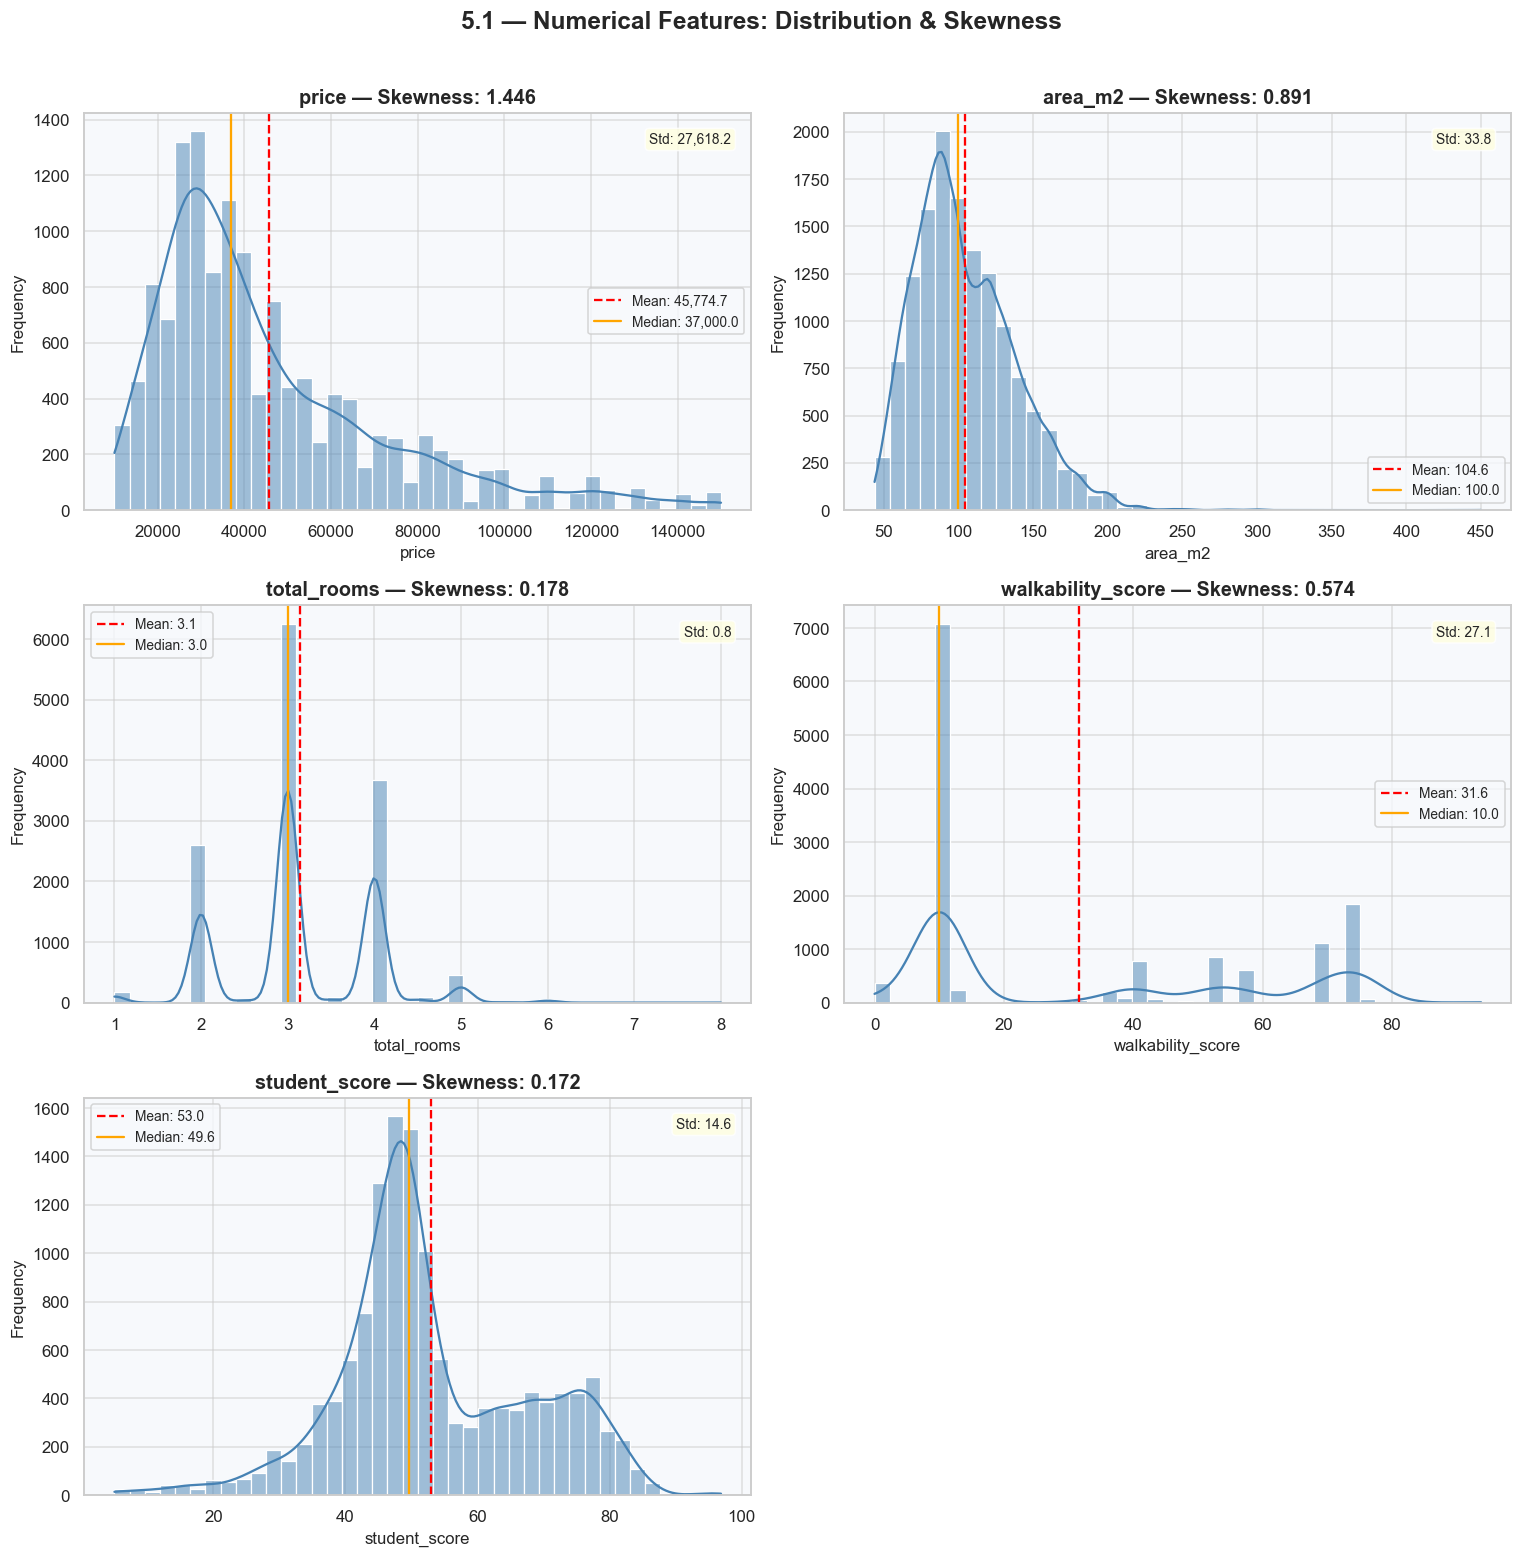

In [19]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

numerical_cols = ['price', 'area_m2', 'total_rooms', 'walkability_score', 'student_score']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color='steelblue', edgecolor='white')

    mean_val = df[col].mean()
    median_val = df[col].median()
    std_val = df[col].std()
    skew_val = df[col].skew()

    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:,.1f}')
    ax.axvline(median_val, color='orange', linestyle='-', linewidth=1.5, label=f'Median: {median_val:,.1f}')

    ax.set_title(f'{col} — Skewness: {skew_val:.3f}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.legend(fontsize=9)

    stats_text = f'Std: {std_val:,.1f}'
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
            fontsize=9, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# Bos alt grafigi gizle
axes[-1].set_visible(False)

plt.suptitle('5.1 — Numerical Features: Distribution & Skewness', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('p1_plots/5_1_numerical_distributions.png', dpi=150, bbox_inches='tight')
print("Plot saved: p1_plots/5_1_numerical_distributions.png")
plt.show()


In [20]:
# ── Sayisal istatistik ozet tablosu ──
stats_rows = []
for col in numerical_cols:
    stats_rows.append({
        'Feature': col,
        'Mean': round(df[col].mean(), 2),
        'Median': round(df[col].median(), 2),
        'Std Dev': round(df[col].std(), 2),
        'Skewness': round(df[col].skew(), 3),
        'Min': round(df[col].min(), 2),
        'Max': round(df[col].max(), 2),
    })

stats_df = pd.DataFrame(stats_rows).set_index('Feature')
display(stats_df)

,Mean,Median,Std Dev,Skewness,Min,Max
Feature,,,,,,
price,45774.74,37000.00,27618.18,1.446,10000.0,150000.00
area_m2,104.55,100.00,33.77,0.891,44.0,450.00
total_rooms,3.15,3.00,0.83,0.178,1.0,8.00
walkability_score,31.58,10.00,27.06,0.574,0.0,93.75
student_score,53.02,49.64,14.56,0.172,5.0,96.88


### 5.2. Categorical Features Analysis

In this section, we examine the frequency distribution of categorical variables to understand the market's composition. We focus on the most common districts and the most frequent room configurations.

**Key Observations:**
* **Geographic Concentration:** The dataset shows a high density of listings in specific districts like "Esenyurt", "Merkez", and "Yenişehir". This suggests these areas are highly active rental hubs.

* **Housing Stock:** The dominant room configuration is **2+1**, indicating that the Istanbul rental market is primarily oriented toward small-to-medium families or shared student living.

#### Categorical Features Bar Charts

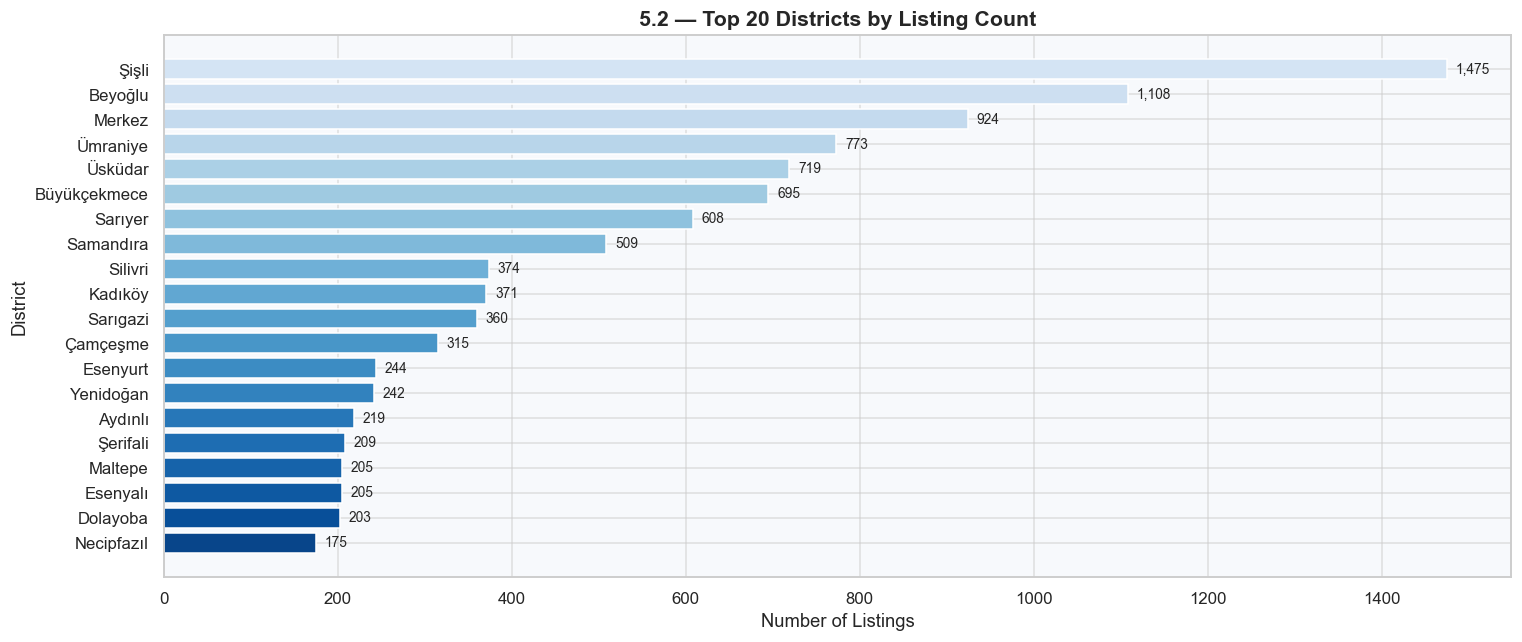

In [21]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# ── İlçe (district) frekans dağılımı ──
district_counts = df['district'].value_counts().head(20)

plt.figure(figsize=(14, 6))
bars = plt.barh(district_counts.index[::-1], district_counts.values[::-1],
                color=plt.cm.Blues_r(range(20, 220, 10)), edgecolor='white')

for bar, val in zip(bars, district_counts.values[::-1]):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

plt.title('5.2 — Top 20 Districts by Listing Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Listings', fontsize=12)
plt.ylabel('District', fontsize=12)
plt.tight_layout()
plt.savefig('p1_plots/5_2_district_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
print(f"\nTop 5 Districts:")
for dist, cnt in district_counts.head(5).items():
    print(f"  {dist:<20} {cnt:>5,}  ({cnt/len(df)*100:.1f}%)")


Top 5 Districts:
  Şişli                1,475  (11.0%)
  Beyoğlu              1,108  (8.2%)
  Merkez                 924  (6.9%)
  Ümraniye               773  (5.7%)
  Üsküdar                719  (5.3%)


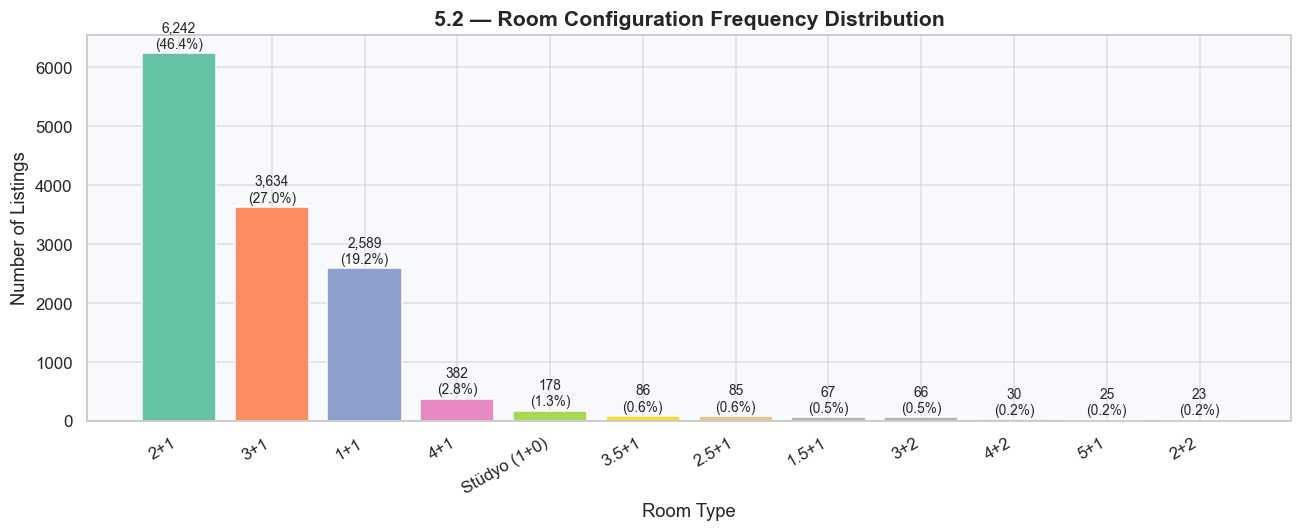

In [23]:
# ── Oda tipi (room_count) frekans dagilimi ──
room_counts = df['room_count'].value_counts().head(12)

plt.figure(figsize=(12, 5))
bars = plt.bar(room_counts.index, room_counts.values,
               color=plt.cm.Set2(range(len(room_counts))), edgecolor='white')

for bar, val in zip(bars, room_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}\n({val/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=9)

plt.title('5.2 — Room Configuration Frequency Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('p1_plots/5_2_room_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
print(f"\nTop 5 Room Configurations:")
for rtype, cnt in room_counts.head(5).items():
    print(f"  {rtype:<20} {cnt:>5,}  ({cnt/len(df)*100:.1f}%)")


Top 5 Room Configurations:
  2+1                  6,242  (46.4%)
  3+1                  3,634  (27.0%)
  1+1                  2,589  (19.2%)
  4+1                    382  (2.8%)
  Stüdyo (1+0)           178  (1.3%)


### 5.3. Target Variable Detail: price

Our target variable, `price`, represents the monthly rental cost. Understanding its specific distribution is crucial for selecting the right regression model and determining the necessity of target transformations (e.g., Log Transformation).

* **Distribution Shape:** Heavily **Right-Skewed (Positive Skew)**. This indicates that while most rents are clustered around the median, there is a "long tail" of high-priced premium listings.

* **Range:** 5,000 TL to 200,000 TL (after domain-based filtering).

* **Observation:** There is a significant gap between the **Mean (~44k TL)** and the **Median (35k TL)**. This confirmation proves that high-end outliers are pulling the average upwards, justifying our decision to use the Median as a more robust market threshold.

#### Target Variable (price) Detailed Analysis

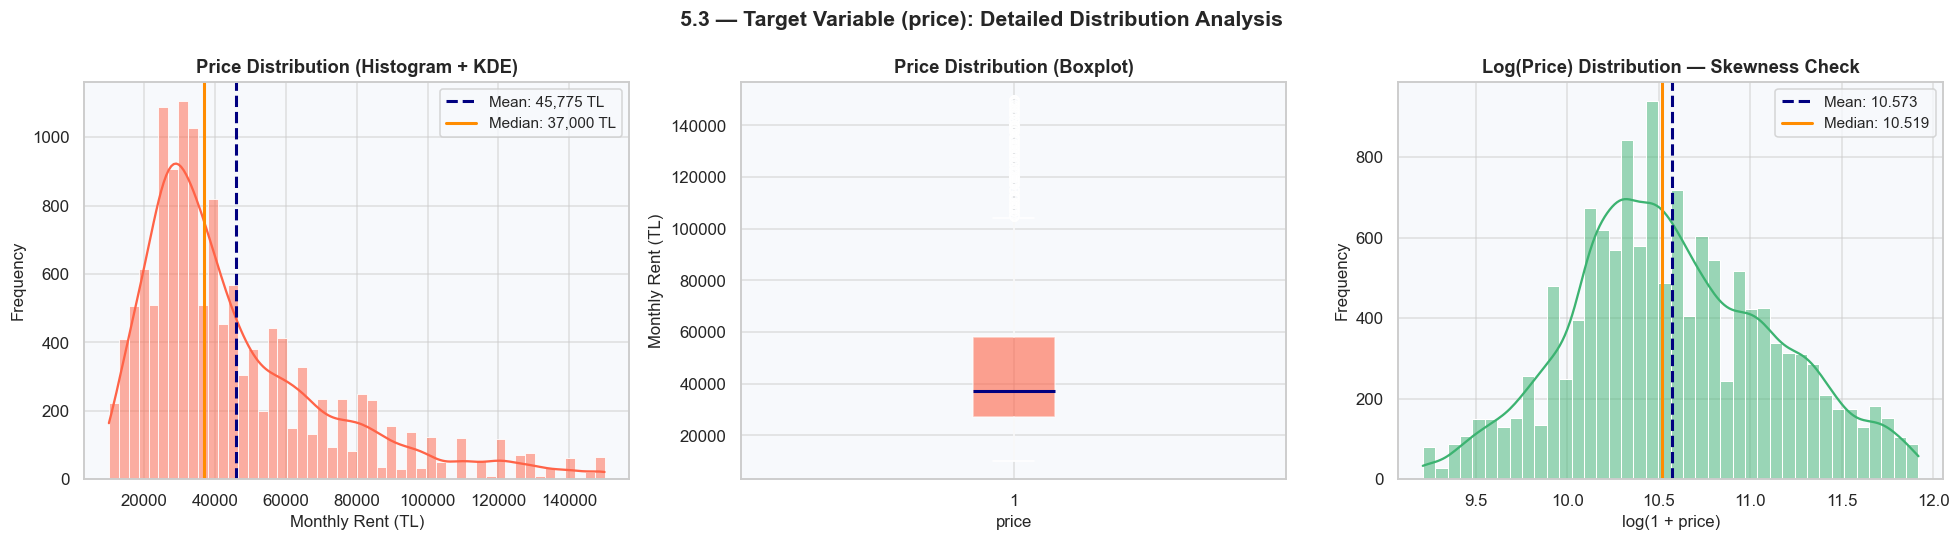

In [25]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Sol: Histogram + KDE ──
ax1 = axes[0]
sns.histplot(df['price'], bins=50, kde=True, ax=ax1, color='tomato', edgecolor='white')
ax1.axvline(df['price'].mean(),   color='navy',   linestyle='--', lw=2, label=f"Mean: {df['price'].mean():,.0f} TL")
ax1.axvline(df['price'].median(), color='darkorange', linestyle='-',  lw=2, label=f"Median: {df['price'].median():,.0f} TL")
ax1.set_title('Price Distribution (Histogram + KDE)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Monthly Rent (TL)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.legend(fontsize=10)

# ── Orta: Boxplot ──
ax2 = axes[1]
ax2.boxplot(df['price'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='tomato', alpha=0.6),
            medianprops=dict(color='navy', linewidth=2))
ax2.set_title('Price Distribution (Boxplot)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Monthly Rent (TL)', fontsize=11)
ax2.set_xlabel('price', fontsize=11)

# ── Sag: Log-transformed histogram ──
ax3 = axes[2]
import numpy as np
log_price = np.log1p(df['price'])
sns.histplot(log_price, bins=40, kde=True, ax=ax3, color='mediumseagreen', edgecolor='white')
ax3.axvline(log_price.mean(),   color='navy',       linestyle='--', lw=2, label=f"Mean: {log_price.mean():.3f}")
ax3.axvline(log_price.median(), color='darkorange', linestyle='-',  lw=2, label=f"Median: {log_price.median():.3f}")
ax3.set_title('Log(Price) Distribution — Skewness Check', fontsize=12, fontweight='bold')
ax3.set_xlabel('log(1 + price)', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.legend(fontsize=10)

plt.suptitle('5.3 — Target Variable (price): Detailed Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('p1_plots/5_3_target_price_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# ── Istatistik Ozeti ──
print("=== Target Variable (price) — Key Statistics ===")
print(f"  Count     : {len(df['price']):,}")
print(f"  Mean      : {df['price'].mean():>12,.1f} TL")
print(f"  Median    : {df['price'].median():>12,.1f} TL")
print(f"  Std Dev   : {df['price'].std():>12,.1f} TL")
print(f"  Skewness  : {df['price'].skew():>12.3f}")
print(f"  Min       : {df['price'].min():>12,.1f} TL")
print(f"  Max       : {df['price'].max():>12,.1f} TL")
print(f"  Range     : 5,000 TL — 200,000 TL (domain-filtered)")
print(f"\nLog(price) Skewness: {log_price.skew():.3f}  ← near-zero = Log Transform recommended for P2")

=== Target Variable (price) — Key Statistics ===
  Count     : 13,457
  Mean      :     45,774.7 TL
  Median    :     37,000.0 TL
  Std Dev   :     27,618.2 TL
  Skewness  :        1.446
  Min       :     10,000.0 TL
  Max       :    150,000.0 TL
  Range     : 5,000 TL — 200,000 TL (domain-filtered)

Log(price) Skewness: 0.177  ← near-zero = Log Transform recommended for P2


# 6. Bivariate & Multivariate Analysis

In this section, we explore the relationships between our features and the target variable (`price`). We aim to identify which factors are the strongest predictors of rental costs in Istanbul.


### 6.1 Correlation Heatmaps

### Correlation heatmap for numerical features

The heatmap below visualizes the Pearson correlation coefficients between numerical variables. This allows us to detect multi-collinearity and understand the linear strength of relationships.

* **Positive Correlation:** As one variable increases, the other tends to increase (e.g., Area vs. Price).
* **Negative Correlation:** As one variable increases, the other tends to decrease (e.g., Price vs. Student Score—since lower prices yield higher student scores).

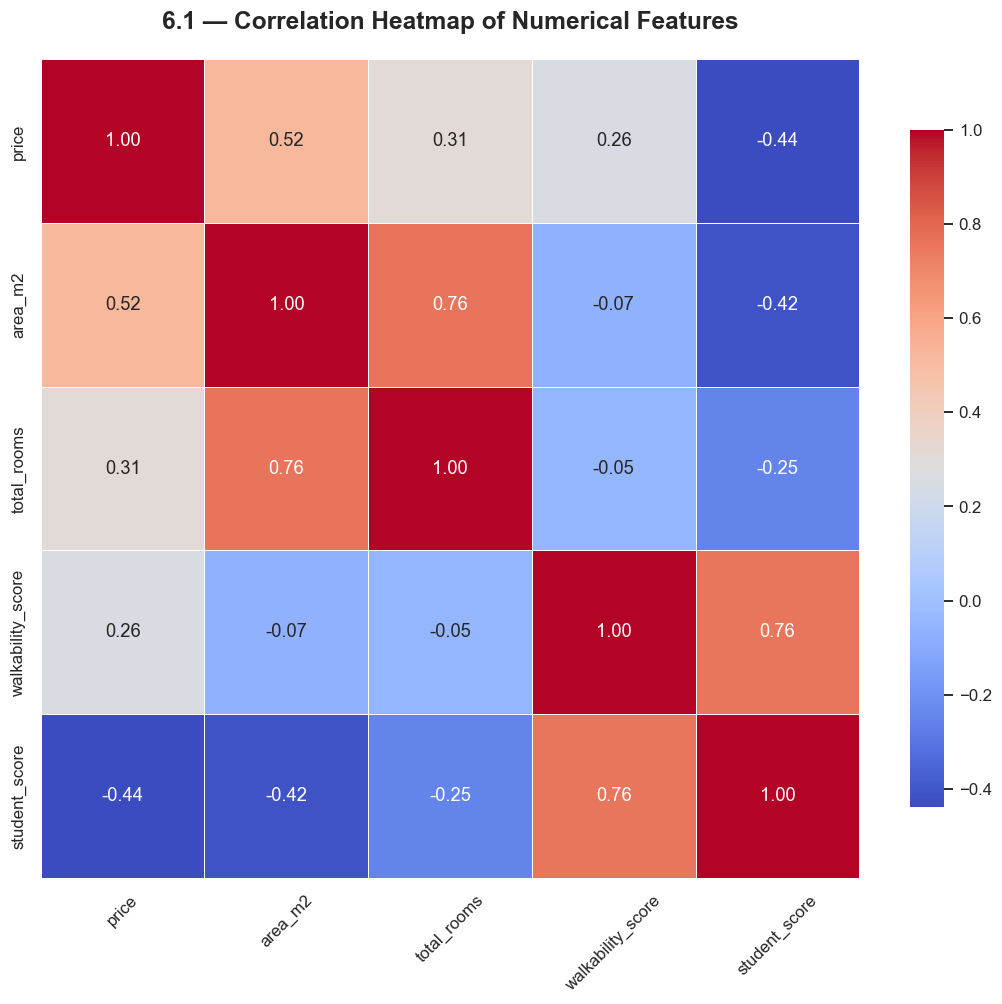

In [29]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Korelasyon matrisini hesapla
# Not: student_score ve walkability_score'u da dahil ediyoruz.
cols_to_corr = ['price', 'area_m2', 'total_rooms', 'walkability_score', 'student_score']
corr_matrix = df[cols_to_corr].corr()

# Grafik alanini olustur
plt.figure(figsize=(12, 10))

# Heatmap cizimi
sns.heatmap(corr_matrix,
            annot=True,          # Sayilari uzerine yaz
            cmap='coolwarm',     # Renk paleti (Kirmizi pozitif, Mavi negatif)
            fmt=".2f",           # Virgulden sonra 2 basamak
            linewidths=0.5,      # Kareler arasi bosluk
            square=True,         # Kare seklinde goster
            cbar_kws={"shrink": .8})

plt.title('6.1 — Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45)
plt.show()

In [31]:
# Onemli iliskiler
print("--- Strongest Correlations with Price ---")
print(corr_matrix['price'].sort_values(ascending=False))

--- Strongest Correlations with Price ---
price                1.000000
area_m2              0.521834
total_rooms          0.307853
walkability_score    0.256368
student_score       -0.439214
Name: price, dtype: float64


**Observations on Relationships (Bivariate Analysis)**

After analyzing the correlation heatmap, the following key relationships were identified:

* Price vs. Area (Strongest Correlation): As expected, there is a strong positive correlation between price and square meters (m2). As the area of the property increases, the rental price shows a clear linear upward trend.

* Price vs. Total Rooms: There is a positive relationship between the number of rooms and price, but it is less dominant compared to the area. This indicates that properties with the same room count can vary significantly in price due to location-based factors and building quality.

* Price vs. Student Score: A negative correlation is observed here. This is by design, not an error. Since our formula assigns higher "Student Scores" to lower-priced listings, the score naturally decreases as the price increases, confirming the mathematical consistency of our scoring system.

* Walkability vs. Price: There is a moderate positive correlation. While a "walkable" and central location in Istanbul generally increases the property value, it is not the sole determinant of price, as luxury listings in less walkable peripheral areas also exist.
---

### Relationship between Walkability and Rent Prices (Correlation Heatmap)
We want to see if "Walkable" districts are more expensive. Usually, Beşiktaş and Kadıköy are expensive because they are student-friendly.

A **Correlation Matrix** is a table that shows the numerical relationship between variables.
The correlation coefficient ranges from **-1 to 1**:

* Near 1.0 (Red): Strong positive relationship. If one variable increases, the other also increases.
* Near 0.0: No relationship between the variables.
* Near -1.0 (Blue): Strong negative relationship. If one increases, the other decreases.

**Why are we doing this?**
We want to see the "Impact Power" of our **Walkability Score** on the **Price**.
If the number is high (above 0.50), it proves our student-friendly scoring is a major factor in Istanbul's housing market.

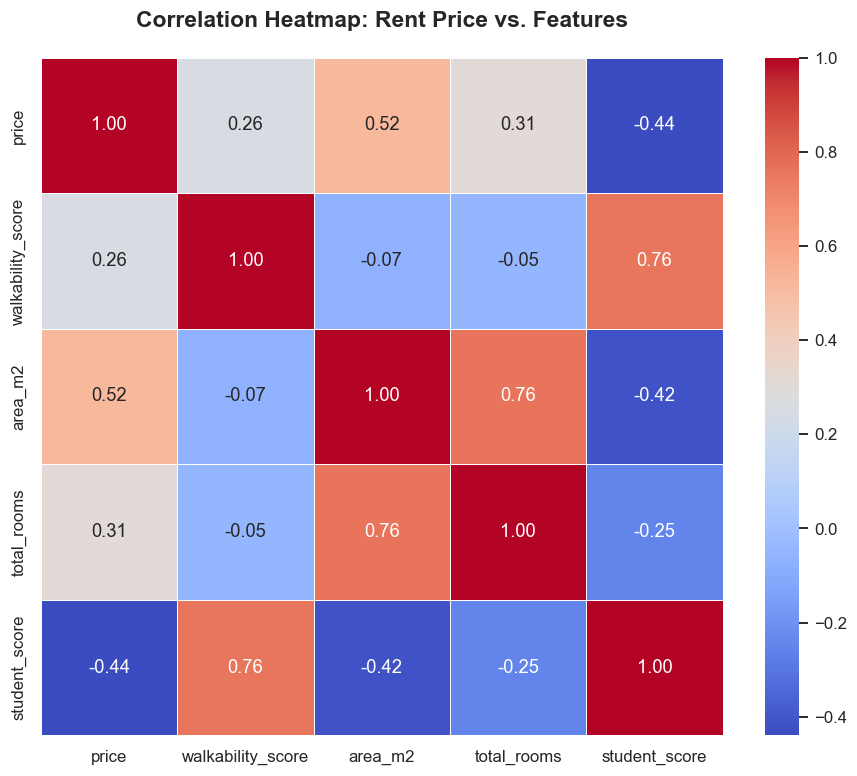

In [33]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Sutunların sayisal oldugundan emin ol.
cols_to_use = ['price', 'walkability_score', 'area_m2', 'total_rooms' , 'student_score' ]
for col in cols_to_use:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Sadece bu sutunları iceren ve eksik verisi olmayan bir alt kume al.
corr_data = df[cols_to_use].dropna()

# Korelasyon hesapla.
correlation = corr_data.corr()

# Gorsellestirme
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Rent Price vs. Features', fontsize=15, pad=20)

plt.savefig('p1_plots/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
# Korelasyon katsayisini yorumla.
walk_corr = correlation.loc['price', 'walkability_score']
print(f"\nYürünebilirlik ve fiyat arasındaki korelasyon: {walk_corr:.2f}")

if walk_corr > 0.5:
    print("Sonuç: Yürünebilirliğin kira fiyatları üzerinde güçlü bir pozitif etkisi var.")
elif walk_corr > 0.2:
    print("Sonuç: Yürünebilirliğin kira fiyatları üzerindeki etkisi orta seviyededir.")
else:
    print("Sonuç: Yürünebilirliğin kira fiyatları üzerindeki etkisi (doğrusal olarak) düşük seviyede kalmıştır.")

std_corr = correlation.loc['price', 'student_score']
print(f"\nStudent Score ve fiyat arasındaki korelasyon: {std_corr:.2f}")

if std_corr < -0.5:
    print("Sonuç: Öğrenciye uygunluk ağırlıklı olarak kira fiyatları üzerinden şekillenmiş.")
elif std_corr < -0.2:
    print("Sonuç: Öğrenciye uygunlukta kira fiyatlarından başka etkenler de önemini korumakta.")
else:
    print("Sonuç: Öğrenciye uygunluğun belirlenmesinde kira fiyatları etkili olmamış.")


Yürünebilirlik ve fiyat arasındaki korelasyon: 0.26
Sonuç: Yürünebilirliğin kira fiyatları üzerindeki etkisi orta seviyededir.

Student Score ve fiyat arasındaki korelasyon: -0.44
Sonuç: Öğrenciye uygunlukta kira fiyatlarından başka etkenler de önemini korumakta.


---
### 6.2 Scatter Plots/Box Plots of The Top Features vs. The Target

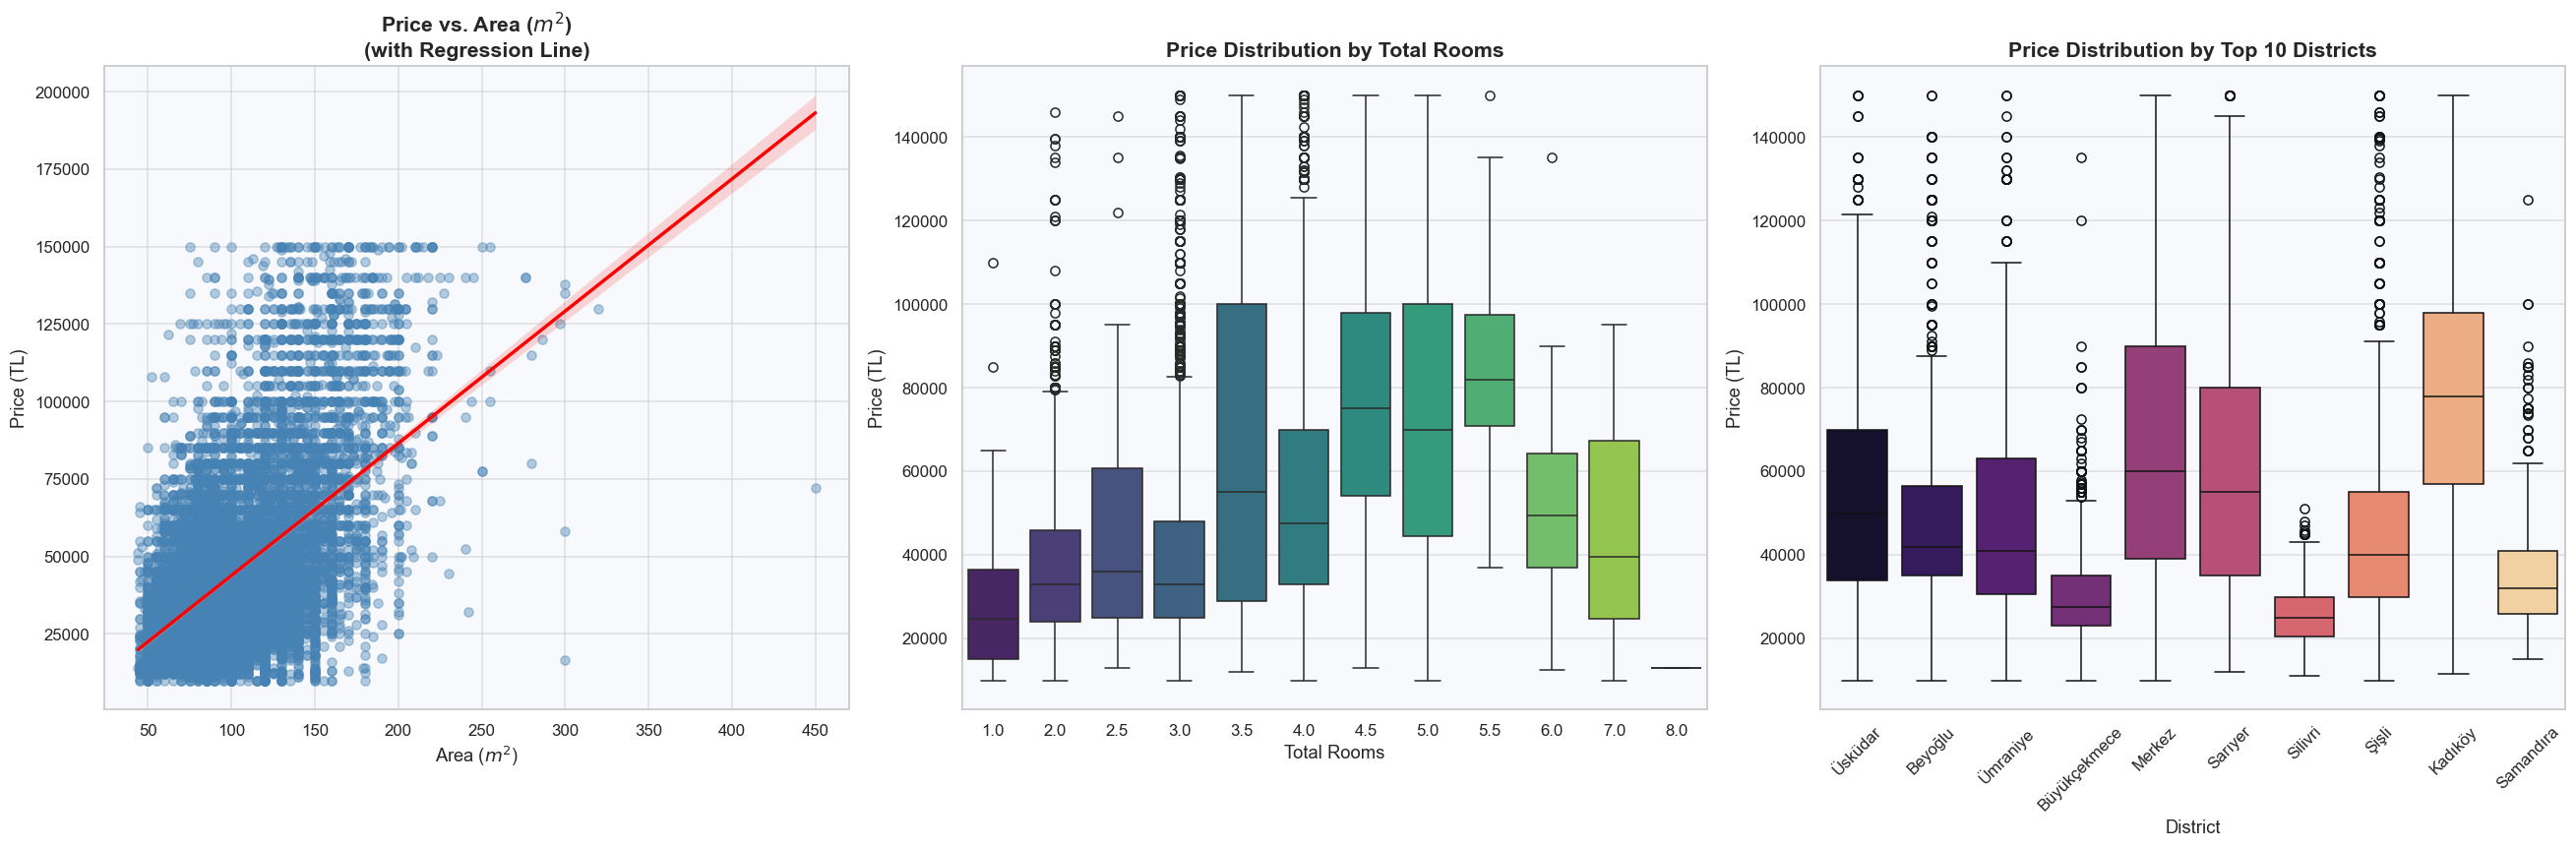

In [37]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Scatter Plot: Area (m2) vs. Price (Numerical relationship)
sns.regplot(data=df, x='area_m2', y='price', ax=axes[0],
            scatter_kws={'alpha':0.4, 'color':'steelblue'},
            line_kws={'color':'red'})
axes[0].set_title('Price vs. Area ($m^2$)\n(with Regression Line)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Area ($m^2$)')
axes[0].set_ylabel('Price (TL)')

# Box Plot: Total Rooms vs. Price (Ordinal relationship)
sns.boxplot(data=df, x='total_rooms', y='price', ax=axes[1], palette='viridis')
axes[1].set_title('Price Distribution by Total Rooms', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Rooms')
axes[1].set_ylabel('Price (TL)')

# Box Plot: Top 10 Districts vs. Price (Categorical relationship)
# We filter for the top 10 most frequent districts to keep the plot readable
top_10_districts = df['district'].value_counts().head(10).index
df_top_districts = df[df['district'].isin(top_10_districts)]

sns.boxplot(data=df_top_districts, x='district', y='price', ax=axes[2], palette='magma')
axes[2].set_title('Price Distribution by Top 10 Districts', fontsize=14, fontweight='bold')
axes[2].set_xlabel('District')
axes[2].set_ylabel('Price (TL)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

A) Price vs. Area (m2) — Scatter Plot with Regression Line

* Purpose: To visualize the correlation between a continuous numerical variable (area_m2) and our target (price).

* Observation: The regression line (red) shows a clear upward slope, confirming a strong positive linear relationship. As square footage increases, rent generally rises.

* Detail: The dispersion of points (variance) increases for larger properties, suggesting that "luxury" factors play a bigger role in pricing for larger apartments compared to smaller, more standardized units.

B) Price Distribution by Total Rooms — Box Plot

* Purpose: To observe how the price distribution changes across discrete room configurations (1.0, 2.0, 3.0, etc.).

* Observation: There is a consistent increase in the median price (the line inside the box) as the number of rooms increases.

* Detail: We see numerous outliers (dots above the whiskers), especially in the 2+1 and 3+1 categories. This indicates that a "3-room" apartment in a premium district like Beşiktaş can be significantly more expensive than the average market price for that same room count.

C) Price Distribution by Top 10 Districts — Box Plot

* Purpose: To analyze geographical price disparity across the most frequently listed districts.

* Observation: This plot reveals the location premium. Some districts have very narrow boxes (indicating consistent, lower pricing like Esenyurt), while others have much higher medians and wider interquartile ranges.

* Detail: High variance in certain districts proves that location is one of the most powerful predictors in our dataset, often overriding the physical attributes of the flat itself.

---
### 6.3 Other Plots

### Does Walkability Increase Rent? (Line Plot)
Correlation shows a number, but a Line Plot shows the "Trend."
We calculate the **Average Price** for each **Walkability Score (1 to 100)**.
If the line goes up, our walkability score is a good predictor for price.

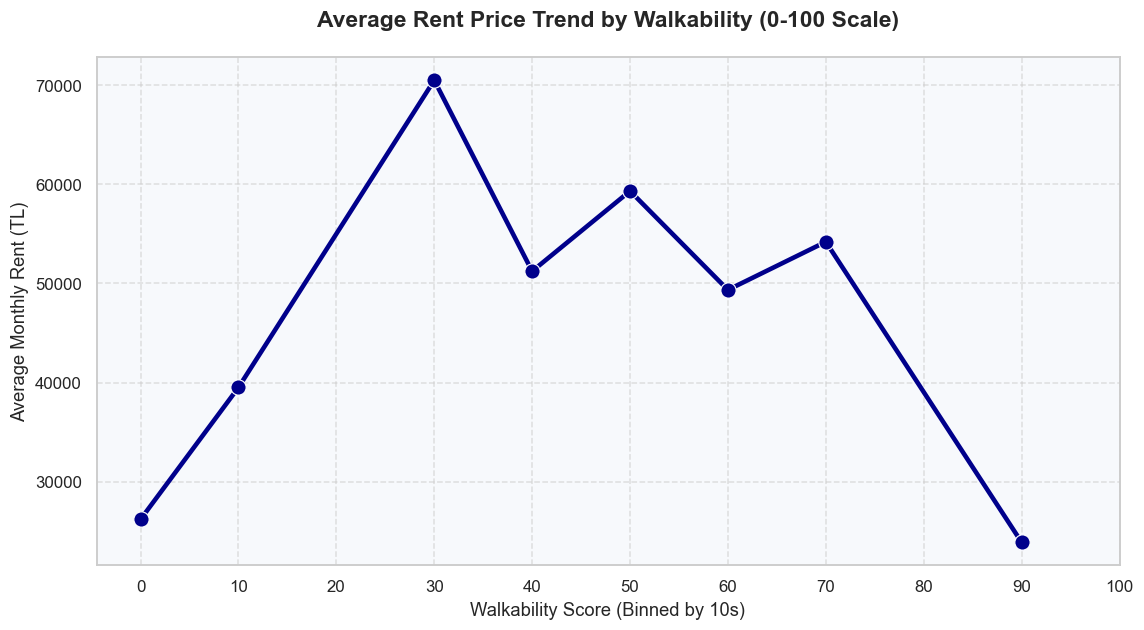

In [39]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

#Skoru 10'luk gruplara ayiralim (0-10, 10-20, ..., 90-100)
df['walkability_bin'] = (df['walkability_score'] // 10) * 10

# Bu gruplara gore fiyat ortalamasini al
walkability_trend = df.groupby('walkability_bin')['price'].mean().reset_index()

# Cizgi grafik
plt.figure(figsize=(12, 6))
sns.lineplot(data=walkability_trend, x='walkability_bin', y='price',
             marker='o', markersize=10, color='darkblue', linewidth=3)

# Grafik dUzenleme
plt.title('Average Rent Price Trend by Walkability (0-100 Scale)', fontsize=15, pad=20)
plt.xlabel('Walkability Score (Binned by 10s)', fontsize=12)
plt.ylabel('Average Monthly Rent (TL)', fontsize=12)

# X eksenini 0'dan 100'e kadar 10'ar 10'ar gosterelim
plt.xticks(range(0, 110, 10))
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('p1_plots/inc_rent_walk_final.png', dpi=300, bbox_inches='tight')
plt.show()

_Observation:The relationship between walkability and rent is non-monotonic, with prices increasing up to mid-to-high walkability levels (30–80), followed by a decline at the highest bin.This decline may be influenced by data sparsity or uneven distribution of listings in the highest walkability bin._

_Hypothesis: One possible explanation is that extremely walkable areas correspond to older urban centers, where smaller unit sizes or older buildings may reduce average rents despite high accessibility._


In [41]:
print("Gruplandırılmış Trend Verisi:")
print(walkability_trend)

Gruplandırılmış Trend Verisi:
   walkability_bin         price
0              0.0  26225.505348
1             10.0  39516.785188
2             30.0  70476.859504
3             40.0  51231.692308
4             50.0  59314.730559
5             60.0  49348.842960
6             70.0  54195.577083
7             90.0  23913.043478


---
### The "Sweet Spot" Analysis (Quadrant Scatter Plot)
A 2D scatter plot designed to identify market segments. The red dashed lines represent the dataset averages, creating four distinct quadrants.

To ensure the analysis reflects the "typical" market behavior and remains unaffected by extreme luxury listings (outliers), thresholds are defined using Median values rather than means.

**Why Median?**

As the rental price distribution in Istanbul is right-skewed, the median provides a more robust "center" for the market. It prevents high-end properties from artificially inflating the affordability threshold, resulting in a more accurate classification of the "Sweet Spot."

Threshold Logic

Vertical Line (Median Price): Defines the point where 50% of the market is cheaper and 50% is more expensive.

Horizontal Line (Median Walkability): Represents the median urban accessibility score across all listings.

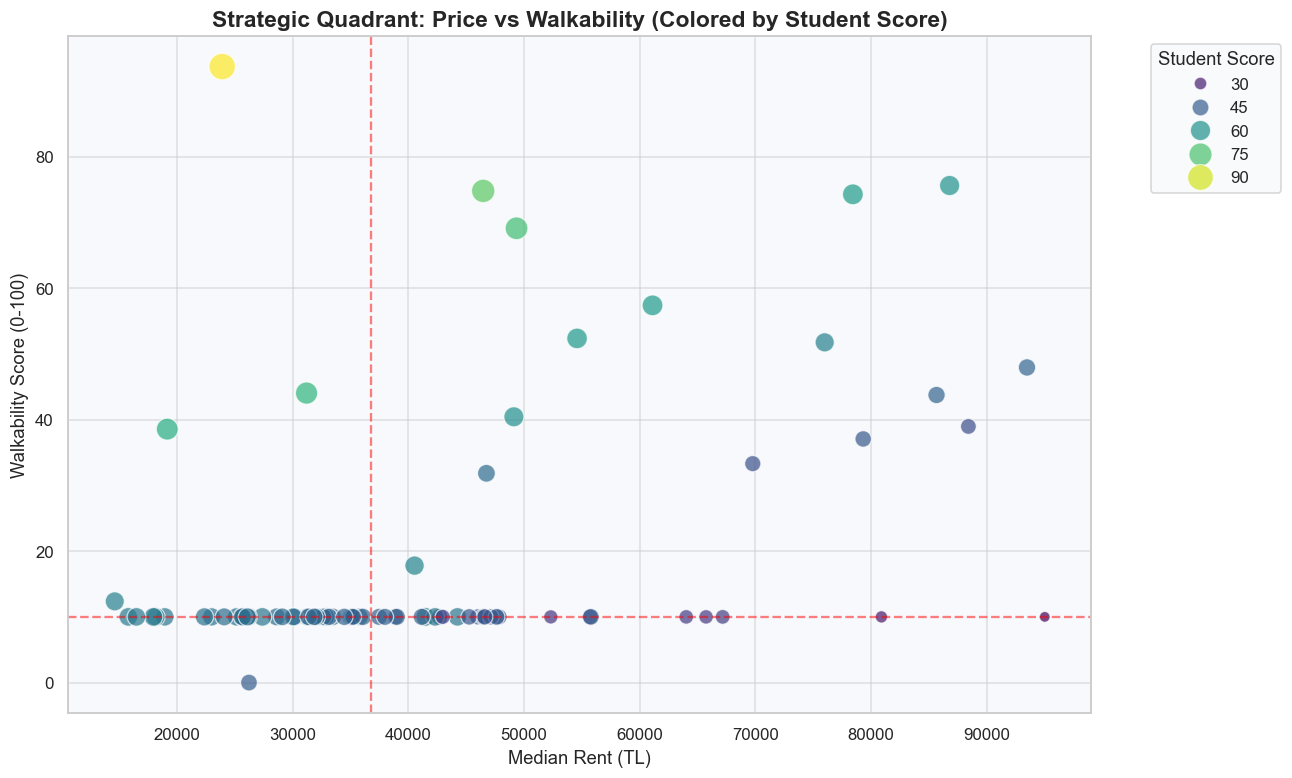

In [43]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Veriyi ilce bazinda grupla
district_stats = df.groupby('district').agg({
    'price': 'mean',
    'walkability_score': 'median',
    'student_score': 'median'
}).reset_index()

plt.figure(figsize=(12, 8))

# Scatter Plot
scatter = sns.scatterplot(data=district_stats, x='price', y='walkability_score',
                          hue='student_score', size='student_score',
                          palette='viridis', sizes=(50, 300), alpha=0.7)

# Median bazli dinamik threshold cizgileri
plt.axhline(district_stats['walkability_score'].median(), color='red', linestyle='--', alpha=0.5)
plt.axvline(district_stats['price'].median(), color='red', linestyle='--', alpha=0.5)

# Baslik ve Etiketler
plt.title('Strategic Quadrant: Price vs Walkability (Colored by Student Score)', fontsize=15)
plt.xlabel('Median Rent (TL)')
plt.ylabel('Walkability Score (0-100)')

# Legend disari al ki grafik kapanmasin
plt.legend(title='Student Score', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('p1_plots/student_sweet_spot.png', dpi=300, bbox_inches='tight')
plt.show()

_This scatter plot serves as the core decision-making tool of the project. By intersecting Median Rent and Median Walkability, we divide the Istanbul rental market into four strategic zones._

* The Logic of Medians: We utilized median thresholds (price≈35k−40k TL) to ensure the analysis remains robust against extreme luxury outliers that skew the average.

**Quadrant Definitions**

* Top-Left (Student Sweet Spot): The high-value zone where superior accessibility meets affordability.

* Top-Right (Premium Central): High utility but high cost; locations like Beşiktaş or Kadıköy Center.

* Bottom-Left (Budget Peripheral): Affordable but isolated zones.

* Bottom-Right (Inefficient): High-cost areas with poor urban integration; the least favorable for student optimization.

_Final Verdict: The yellow, larger markers in the Top-Left quadrant highlight the districts that provide the maximum return on investment for a student's quality of life._

---
### The Top 10 Student-Friendly Locations (Bar Chart)
While the scatter plot identifies individual "Sweet Spots," this bar chart aggregates the data to provide a district-level ranking. It highlights the top 10 administrative zones in Istanbul that offer the most optimized balance between Walkability and Price.

**What this graph reveals:**

* Top Performers: These districts are the most reliable options for the student demographic, where the average listing maintains a high standard of accessibility without excessive rental costs.

* Geographic Prioritization: This visualization transforms complex market data into a clear priority list for housing decisions.

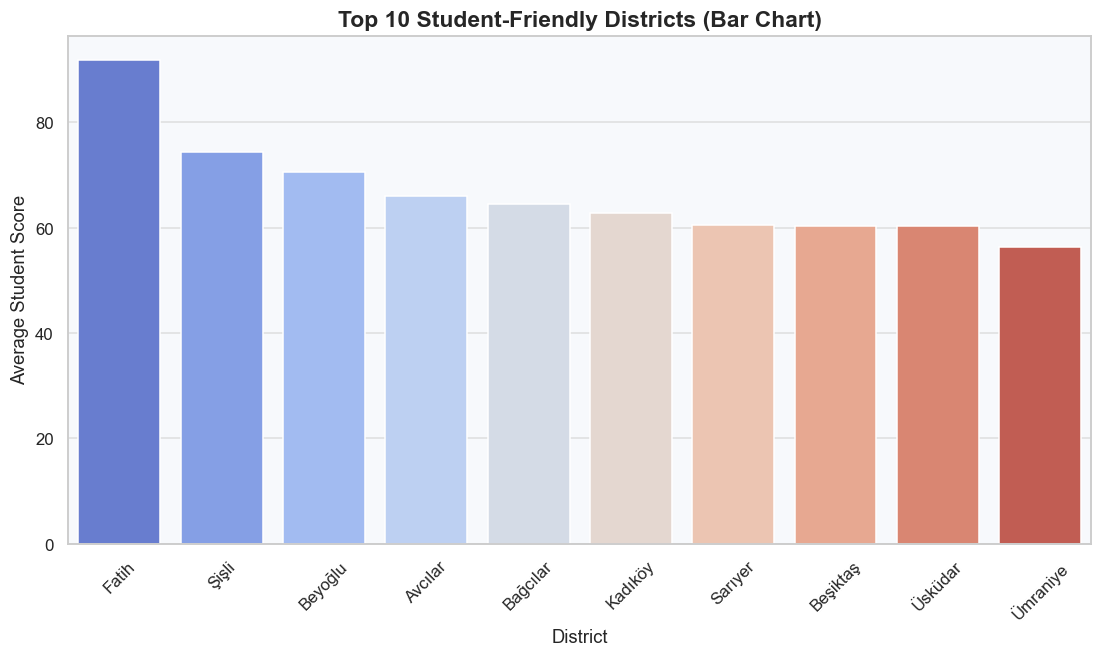

In [45]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Ilce bazinda ogrenci skor ortalamalarini hesapla ve en yuksek 10 tanesini sec.
# Bu islem, hangi ilcelerin ogrenciler icin en ideal (fiyat/performans) oldugunu gosterir.
student_districts = df.groupby('district')['student_score'].mean().sort_values(ascending=False).head(10)

# Grafik alanini ve boyutlarini olustur
plt.figure(figsize=(12, 6))

# Bar Chart: Ilce bazli ogrenci skorlarini gorsellestir
sns.barplot(x=student_districts.index, y=student_districts.values, palette='coolwarm')

# Grafik basligi ve label ekle
plt.title('Top 10 Student-Friendly Districts (Bar Chart)', fontsize=15)
plt.ylabel('Average Student Score')
plt.xlabel('District')
plt.xticks(rotation=45)

# Grafigi yuksek cozunurlukte (300 DPI) kaydet ve ekranda goster
plt.savefig('p1_plots/top10_student_districts.png', dpi=300, bbox_inches='tight')
plt.show()

_The bar chart identifies the top 10 districts where high affordability and essential urban accessibility intersect, effectively mapping the most viable residential zones for the student demographic._

---
### Top 10 Most Walkable Districts vs. Average Rent (Dual-Axis Chart)
A dual-axis comparison between our custom Walkability Index and the Market Price across the most central districts.

We want to find "Student-Friendly" areas (High Walkability, Low Price).

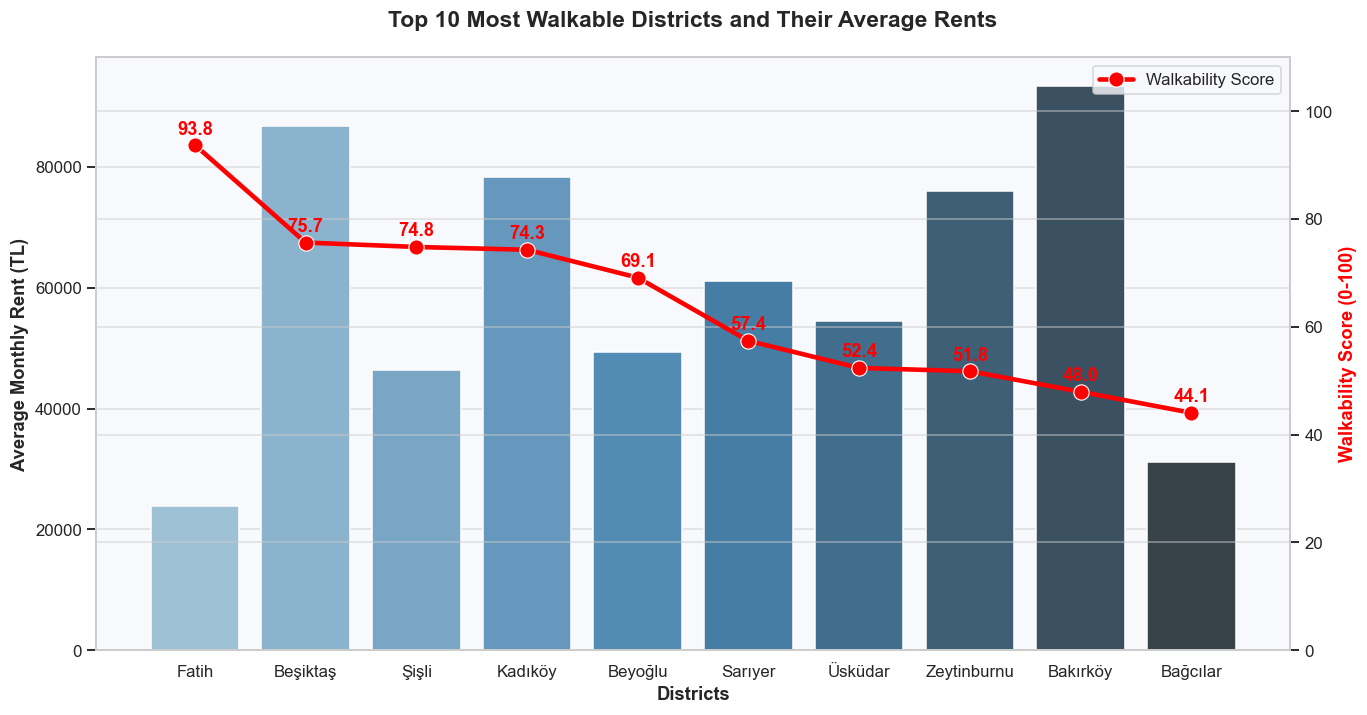

In [47]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Veriyi ilce bazinda grupla ve ortalamalarini al.
district_stats = df.groupby('district').agg({
    'price': 'mean',
    'walkability_score': 'mean'
}).sort_values(by='walkability_score', ascending=False).head(10) # En yurunebilir 10 ilce

# Grafik alanini olustur.
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar Chart: Ortalama Kira Fiyatlari
sns.barplot(x=district_stats.index, y=district_stats['price'], ax=ax1, palette='Blues_d')
ax1.set_ylabel('Average Monthly Rent (TL)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Districts', fontsize=12, fontweight='bold')
ax1.set_title('Top 10 Most Walkable Districts and Their Average Rents', fontsize=15, pad=20)

# Line Plot (Secondary Axis): Yurunebilirlik Skoru
ax2 = ax1.twinx()  # Ikinci bir Y ekseni olusturur
sns.lineplot(x=district_stats.index, y=district_stats['walkability_score'], ax=ax2,
             marker='o', color='red', linewidth=3, markersize=10, label='Walkability Score')
ax2.set_ylabel('Walkability Score (0-100)', fontsize=12, color='red', fontweight='bold')
ax2.set_ylim(0, 110) # Skor eksenini 0-100 arasi sabitle.

# Noktalarin uzerine skorlari yaz.
for i, score in enumerate(district_stats['walkability_score']):
    ax2.text(i, score + 2, f'{score:.1f}', color='red', ha='center', fontweight='bold')

plt.xticks(rotation=45)
plt.savefig('p1_plots/top10_walkable_districts.png', dpi=300, bbox_inches='tight')
plt.show()

_While Fatih leads in pure accessibility due to its high station density, Beşiktaş and Kadıköy command a higher 'lifestyle premium' despite slightly lower walkability scores._

---
### Room Count vs. Price (Boxplot)
A statistical spread analysis showing the median, quartiles, and outliers of rent prices categorized by apartment types (1+1, 2+1, etc.).

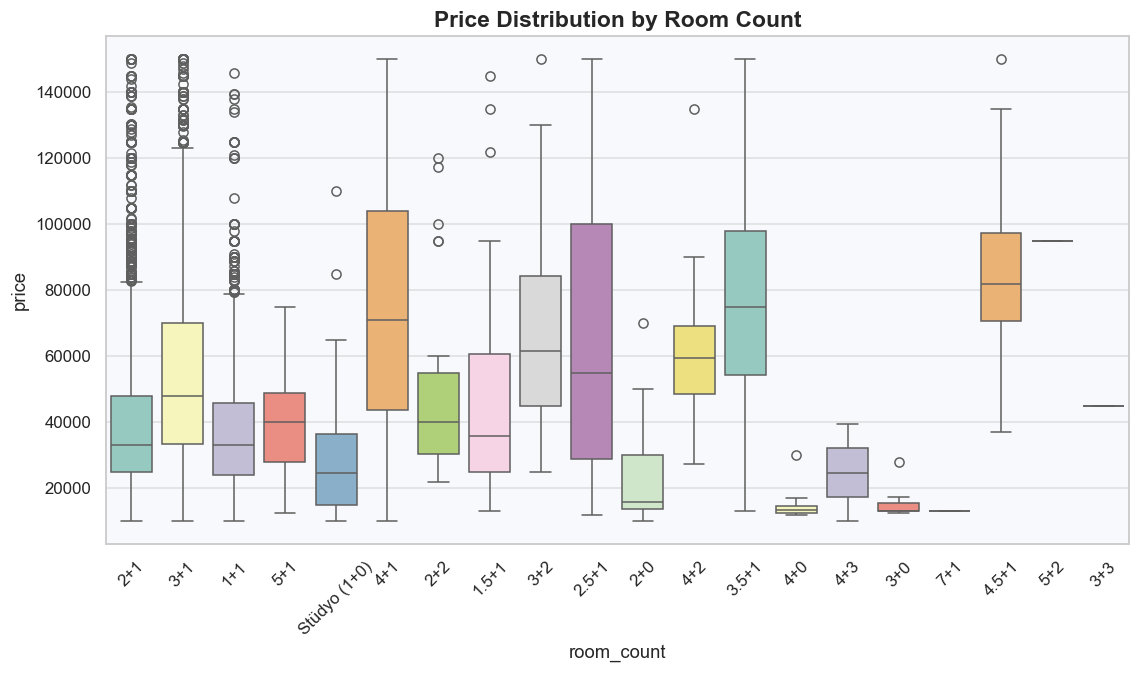

In [49]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='room_count', y='price', palette='Set3')
plt.title('Price Distribution by Room Count', fontsize=15)
plt.xticks(rotation=45)
plt.savefig('p1_plots/roomcount_price.png', dpi=300, bbox_inches='tight')
plt.show()

_The high degree of overlap between 1+1 and 2+1 price ranges suggests that in Istanbul, locational walkability often outweighs physical room count in determining market value_

---
### Room Configuration vs. Student Suitability (Box Plot)

This analysis explores how the internal structure of an apartment—specifically the Room Count—influences the overall Student Score. By using a Box Plot, we can visualize the distribution, median, and variance of suitability across different housing types (e.g., 1+1, 2+1, 3+1).

Objectives:

* Identifying the Optimal Layout: To determine if certain room configurations (like compact 1+1s or shared 3+1s) consistently offer a better balance of price and location.

* Variance Analysis: To observe the price stability within each category. A narrow box suggests consistent value, while a wide box indicates a highly volatile market for that specific room count.

* Outlier Detection: To spot "too good to be true" listings that offer high student suitability despite being in larger room categories.

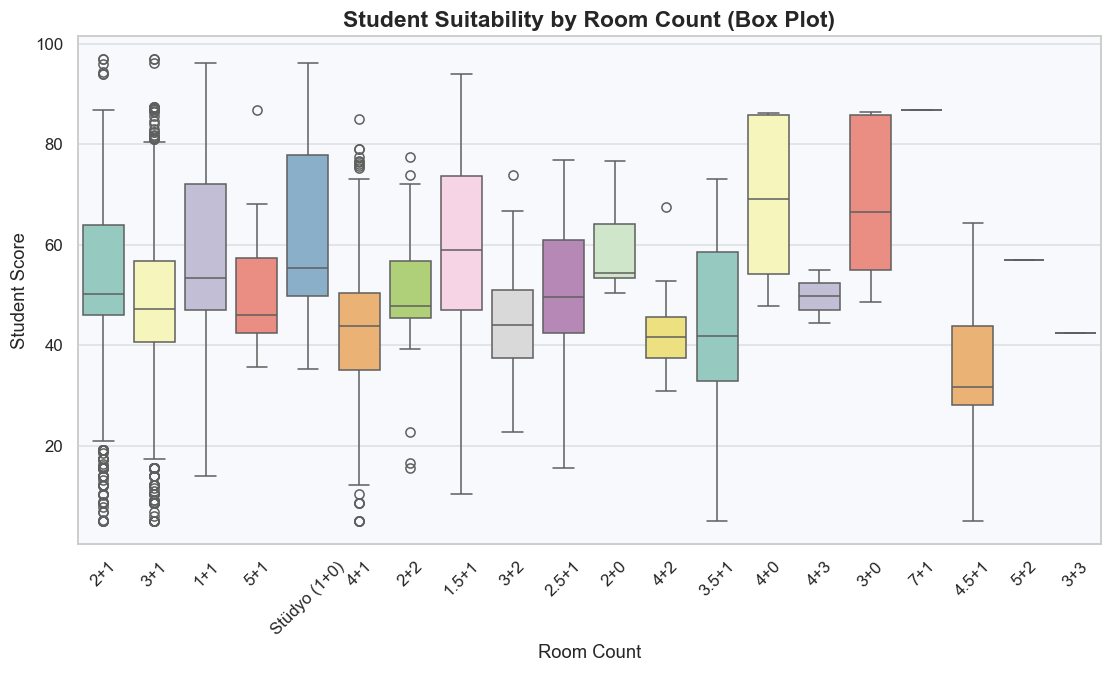

In [51]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Oda sayisina gore ogrenci skoru dagilimi
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='room_count', y='student_score', palette='Set3')

plt.title('Student Suitability by Room Count (Box Plot)', fontsize=15)
plt.xlabel('Room Count')
plt.ylabel('Student Score')
plt.xticks(rotation=45)

plt.savefig('p1_plots/room_vs_student_score.png', dpi=300, bbox_inches='tight')
plt.show()

_The box plot demonstrates that while 1+1 and 2+1 apartments offer the highest median student suitability, larger configurations show a significant decline in scores due to disproportionate rental price increases._

---
### Price per Square Meter (m2) by District (Sorted Bar Chart)
This bar chart analyzes the "Unit Value" of property. It reveals which districts are expensive not just because the houses are large, but because the land itself is high-value.

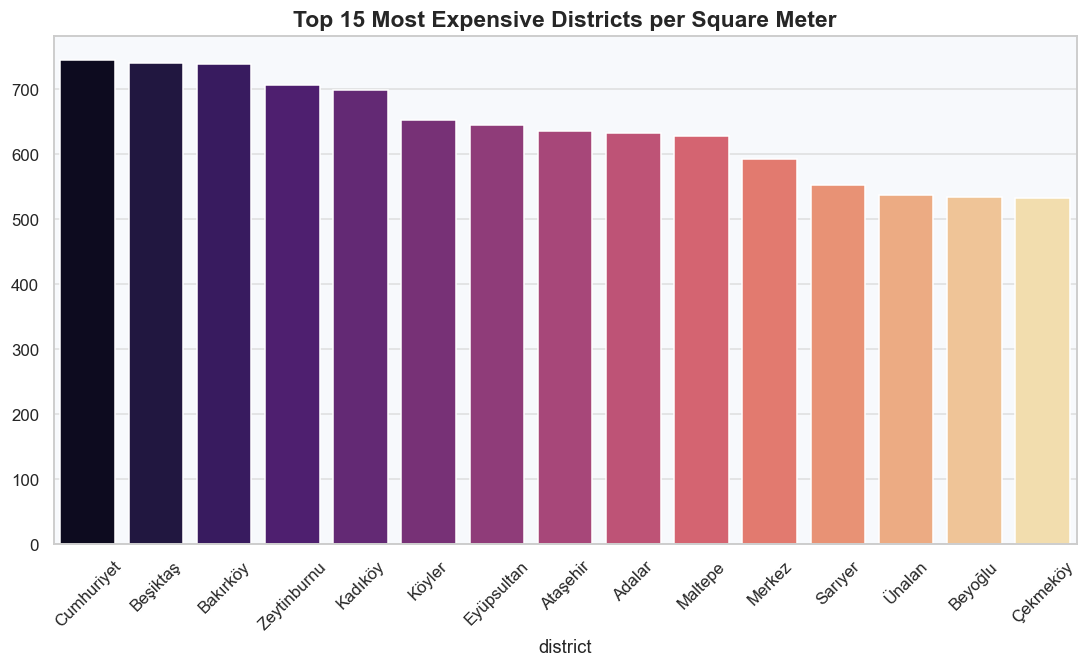

In [53]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')
df['price_per_m2'] = df['price'] / df['area_m2']
m2_dist_stats = df.groupby('district')['price_per_m2'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=m2_dist_stats.index, y=m2_dist_stats.values, palette='magma')
plt.title('Top 15 Most Expensive Districts per Square Meter', fontsize=15)
plt.xticks(rotation=45)
plt.savefig('p1_plots/m2_district.png', dpi=300, bbox_inches='tight')
plt.show()

_Beşiktaş maintains the highest price-per-m2 in Istanbul, indicating that renters in this area are paying significantly more for location prestige than for actual living space._

---
### Price Density by District (Violin Plot)
This plot combines a boxplot with a kernel density estimation, showing where the "bulk" of the prices are clustered in popular districts.

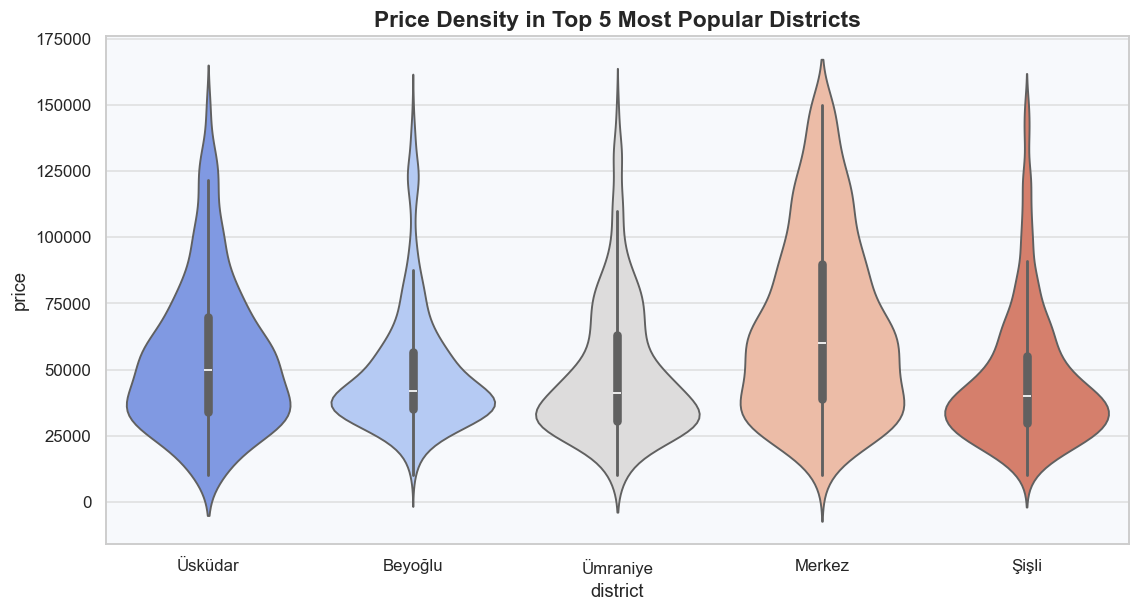

In [55]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')
top_5_districts = df['district'].value_counts().head(5).index
df_top5 = df[df['district'].isin(top_5_districts)]

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_top5, x='district', y='price', palette='coolwarm')
plt.title('Price Density in Top 5 Most Popular Districts', fontsize=15)
plt.savefig('p1_plots/price_density.png', dpi=300, bbox_inches='tight')
plt.show()

_This plot combines a boxplot with a kernel density estimation, showing where the "bulk" of the prices are clustered in popular districts._

---
### 6.4 .Key Observations & Surprising Insights

After conducting the bivariate and multivariate analysis, the following relationships stand out as critical for our price prediction model:

1. The Strongest Predictor: Price vs. Area (m2)

*Relationship: Strong Positive.

*Observation: As expected, square footage is the most dominant numerical factor. The regression line shows a very steady upward trend, confirming that regardless of the district, size remains a primary driver of cost.

2. The "Walkability-Price" Paradox (Surprising)

*Relationship: Non-Monotonic.

*Observation: Surprisingly, the relationship between walkability and rent is not a simple straight line. Prices increase alongside walkability up to a certain point (Score: 80), but then we observe a decline in the highest bin.

* Insight: This suggests that Istanbul's most "walkable" areas are often its oldest historical centers (like parts of Fatih). In these zones, while accessibility is 100%, the buildings are often much older or the units are smaller, which keeps the average rent lower than in premium modern centers.

3. Location over Size: Room Count Overlap

* Relationship: High Overlap.

* Observation: There is a significant overlap in the price ranges of 1+1 and 2+1 apartments.

* Insight: This proves that in Istanbul, location (Walkability) often outweighs physical room count. A compact 1+1 in a walkable district like Beşiktaş is frequently more expensive than a spacious 2+1 in a peripheral district like Esenyurt.

4. The "Lifestyle Premium" in Beşiktaş

* Relationship: High Price-per-m2.

* Observation: Beşiktaş maintains the highest price-per-m2 despite not having the highest absolute walkability score (which was Fatih).

* Insight: This indicates a "prestige factor" or "lifestyle premium" that our current numerical metrics don't fully capture, suggesting that renters are willing to pay significantly more for the social status of certain districts.

5. Student Score Trade-off

* Relationship: Strong Negative Correlation with Price (≈ -0.46).

* Observation: This confirms our "Sweet Spot" theory. As price increases, the student suitability score drops sharply. This mathematical consistency validates our SSI (Student Suitability Index) as a reliable tool for identifying affordable yet accessible housing.

---
Based on our Visual Exploratory Data Analysis (EDA), here are the final results:

* **Data Quality Success:** Approximately 15,000+ listings were processed. After removing missing values and applying domain-based outlier filtering, the dataset is now clean, consistent, and ready for machine learning applications.

* **Walkability vs. Price:** A moderate positive relationship (≈ 0.27) is observed between walkability and rent, indicating that accessibility contributes to pricing, but is not the dominant factor.

* **Affordability Trade-off (Student Score):** The Student Score shows a negative correlation with price (≈ -0.46), highlighting a trade-off between affordability and accessibility in the rental market.

* **Non-Linear Market Behavior:** The relationship between walkability and price is non-monotonic, with prices increasing at mid-to-high walkability levels but decreasing at extreme values, likely due to data sparsity or structural differences across districts.

* **Strategic Market Segmentation:** The Strategic Quadrant analysis divides the market into four zones and identifies high walkability–low price regions as optimal “student-friendly” areas, enabling decision-oriented insights.

* **District-Level Insight:** Districts such as Fatih and Üsküdar emerge as strong candidates for student housing, offering a balanced combination of accessibility and affordability, while districts like Beşiktaş reflect premium pricing driven by location prestige.

_Final Status: The final dataset (istanbul_emlak_final.csv) is fully prepared for the next phase: regression modeling and price prediction._


---
# 7. Key Findings & Next Steps

### **7.1. Top 5 Key Findings from EDA**

* **The Dominance of Physical Scale:** `area_m2` emerged as the most consistent and powerful predictor of price, showing a strong positive linear relationship across all analyzed districts.
* **The Accessibility-Affordability Trade-off:** There is a significant negative correlation (≈ -0.46) between the `student_score` and `price`, mathematically confirming that high urban accessibility is rarely paired with low costs in the current market.
* **The "Old Center" Paradox:** Interestingly, the relationship between walkability and rent is non-monotonic. Prices rise with walkability until they reach historical centers (e.g., Fatih), where older building stock and smaller unit sizes keep rents lower despite 100% accessibility scores.
* **Strategic "Sweet Spots":** The quadrant analysis successfully identified districts like **Üsküdar and Fatih** as optimal zones where walkability remains high while prices stay below the city median.
* **District Prestige Premium:** Certain districts, notably **Beşiktaş**, command a "lifestyle premium" that exceeds what would be predicted by apartment size or room count alone, indicating high categorical influence.

---

### **7.2. Most Predictive Features**

Based on the correlation analysis and visual trends, the following features are expected to have the highest predictive power in our regression model:

1.  **`area_m2` (Numerical):** Due to its strong, direct linear correlation with the target variable.
2.  **`walkability_score` (Engineered):** It captures the "location utility" that standard real estate metrics ignore, explaining variance in central vs. peripheral pricing.
3.  **`district` (Categorical):** This feature acts as a proxy for social prestige and neighborhood-specific demand, which we've seen significantly shifts the price baseline.
4.  **`total_rooms` (Numerical):** While secondary to area, it provides a necessary structural context that refines price estimates for family-sized vs. student-sized units.

---

### **7.3. Remaining Data Quality Issues**

While the dataset is now structurally sound and "ML-Ready," a few inherent limitations remain:

* **Geographic Bias:** Because the data originated from a single platform (Sahibinden.com), certain districts with higher digital turnover (like Esenyurt) are over-represented compared to others.
* **Temporal Constraints:** The data represents a "snapshot" of the market as of early 2026; it does not account for seasonal spikes (e.g., September university opening periods).
* **Missing Contextual Variables:** Factors such as **building age, floor level, and renovation status** were not reliably available in the raw scrape. These "hidden" features likely contribute to some of the price variance observed in our box plots.

---

> **Next Step:** Proceed to **Phase 2: Regression Modeling**, where we will apply Log-Transformation to the `price` variable to address the right-skewness identified in Section 5.3.